# Statistics for Michel electron candidate

### Created by Shu, 202508 & 202509 & 202510---

#### To explore decay points distribution asymmetry along drift direction

#### (20250916) Main update here is the introduction of CLASS, to upgrade current cumbersome data processing

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

In [1]:
from dataclasses import dataclass
import os

# ----------------------------- Dataclass ------------------------------------
@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    energy_initial: float = None
    lifetime_initial: float = None
    pdg_initial: int = None
    eventID_initial: int = None
    trackID_initial: int = None


# ----------------------------- Helpers --------------------------------------
def read_values(file_path, cast_type=float):
    """Read a single file into a list."""
    values = []
    if not os.path.exists(file_path):
        print(f"[WARN] Missing file: {file_path}")
        return values
    with open(file_path, "r") as f:
        for line in f:
            val = line.strip()
            if val:
                try:
                    values.append(cast_type(val))
                except ValueError:
                    print(f"[WARN] Could not parse '{val}' in {file_path}")
    return values


def read_multiple(file_paths, cast_type=float):
    """Read multiple files and concatenate them."""
    combined = []
    for path in file_paths:
        combined.extend(read_values(path, cast_type))
    return combined


# ----------------------------- Configuration --------------------------------
data_dir = "./statResult_tpc"
dates_all = [
    "20251010", "20251011", "20251012", "20251013", "20251014", "20251015", "20251016", "20251017", "20251018", "20251019",
    "20251020", "20251021", "20251022", "20251023", "20251024", "20251025", "20251026", "20251027", "20251028", "20251029",
    "20251030", "20251031", "20251032"]

# map: class attribute -> (file prefix, value type)
fields_info = {
    "decayX_initial": ("decayX", float),
    "decayY_initial": ("decayY", float),
    "decayZ_initial": ("decayZ", float),
    "startX_initial": ("startX", float),
    "startY_initial": ("startY", float),
    "startZ_initial": ("startZ", float),
    "MS_initial": ("michelScore", float),
    "MH_initial": ("michelHits", float),
    "energy_initial": ("energy", float),
    "lifetime_initial": ("lifetime", float),
    "pdg_initial": ("pdg", int),
    "eventID_initial": ("eventID", int),
    "trackID_initial": ("trackID", int),
}

# ----------------------------- File Reading ---------------------------------
data = {}

for field, (stub, cast_type) in fields_info.items():
    files = [f"{data_dir}/{stub}_New{d}_initial.txt" for d in dates_all]
    values = read_multiple(files, cast_type)
    data[field] = values
    print(f"[INFO] Loaded {field} ({len(values)} entries)")

# ----------------------------- Build Events ---------------------------------
n_events = len(next(iter(data.values())))
events_reco = [
    ParticleEvent(**{k: data[k][i] if i < len(data[k]) else None for k in data})
    for i in range(n_events)
]

print(f"[OK] Created {len(events_reco)} ParticleEvent objects.")


print("Candidates ( MH > xxx): ", len(events_reco))

print("\nExample: ")
print(events_reco[0].decayX_initial)
print(events_reco[0].energy_initial)
print(events_reco[0].pdg_initial)




# ----------------------------- Create Lists for Direct Access ----------------
# Create standalone lists (just like your old style)
decayX_initial   = data["decayX_initial"]
decayY_initial   = data["decayY_initial"]
decayZ_initial   = data["decayZ_initial"]
startX_initial   = data["startX_initial"]
startY_initial   = data["startY_initial"]
startZ_initial   = data["startZ_initial"]
MS_initial       = data["MS_initial"]
MH_initial       = data["MH_initial"]
energy_initial   = data["energy_initial"]
lifetime_initial = data["lifetime_initial"]
pdg_initial      = data["pdg_initial"]
eventID_initial  = data["eventID_initial"]
trackID_initial  = data["trackID_initial"]





#True Michel events----------
events_true = []
trueE_num = 0
trueL_num = 0
for ev in events_reco:
    if ev.energy_initial > 0:
        trueE_num += 1
        events_true.append(ev)
    if ev.lifetime_initial > 0:
        trueL_num += 1

print("\n# of True events: ", len(events_true))
print("Events with E > 0 (true Michel): ", trueE_num, "({:.2f}%)".format(trueE_num/len(events_reco)*100))
print("Events with L > 0 (true Michel): ", trueL_num, "({:.2f}%)".format(trueL_num/len(events_reco)*100))



[INFO] Loaded decayX_initial (451453 entries)
[INFO] Loaded decayY_initial (451453 entries)
[INFO] Loaded decayZ_initial (451453 entries)
[INFO] Loaded startX_initial (451453 entries)
[INFO] Loaded startY_initial (451453 entries)
[INFO] Loaded startZ_initial (451453 entries)
[INFO] Loaded MS_initial (451453 entries)
[INFO] Loaded MH_initial (451453 entries)
[INFO] Loaded energy_initial (451453 entries)
[INFO] Loaded lifetime_initial (451453 entries)
[INFO] Loaded pdg_initial (451453 entries)
[INFO] Loaded eventID_initial (451453 entries)
[INFO] Loaded trackID_initial (451453 entries)
[OK] Created 451453 ParticleEvent objects.
Candidates ( MH > xxx):  451453

Example: 
70.135
-1.0
0

# of True events:  95925
Events with E > 0 (true Michel):  95925 (21.25%)
Events with L > 0 (true Michel):  95925 (21.25%)



Decay points distribution: 
# of X < 0 :  206335 (45.70%)
# of X >= 0:  245118 (54.30%)


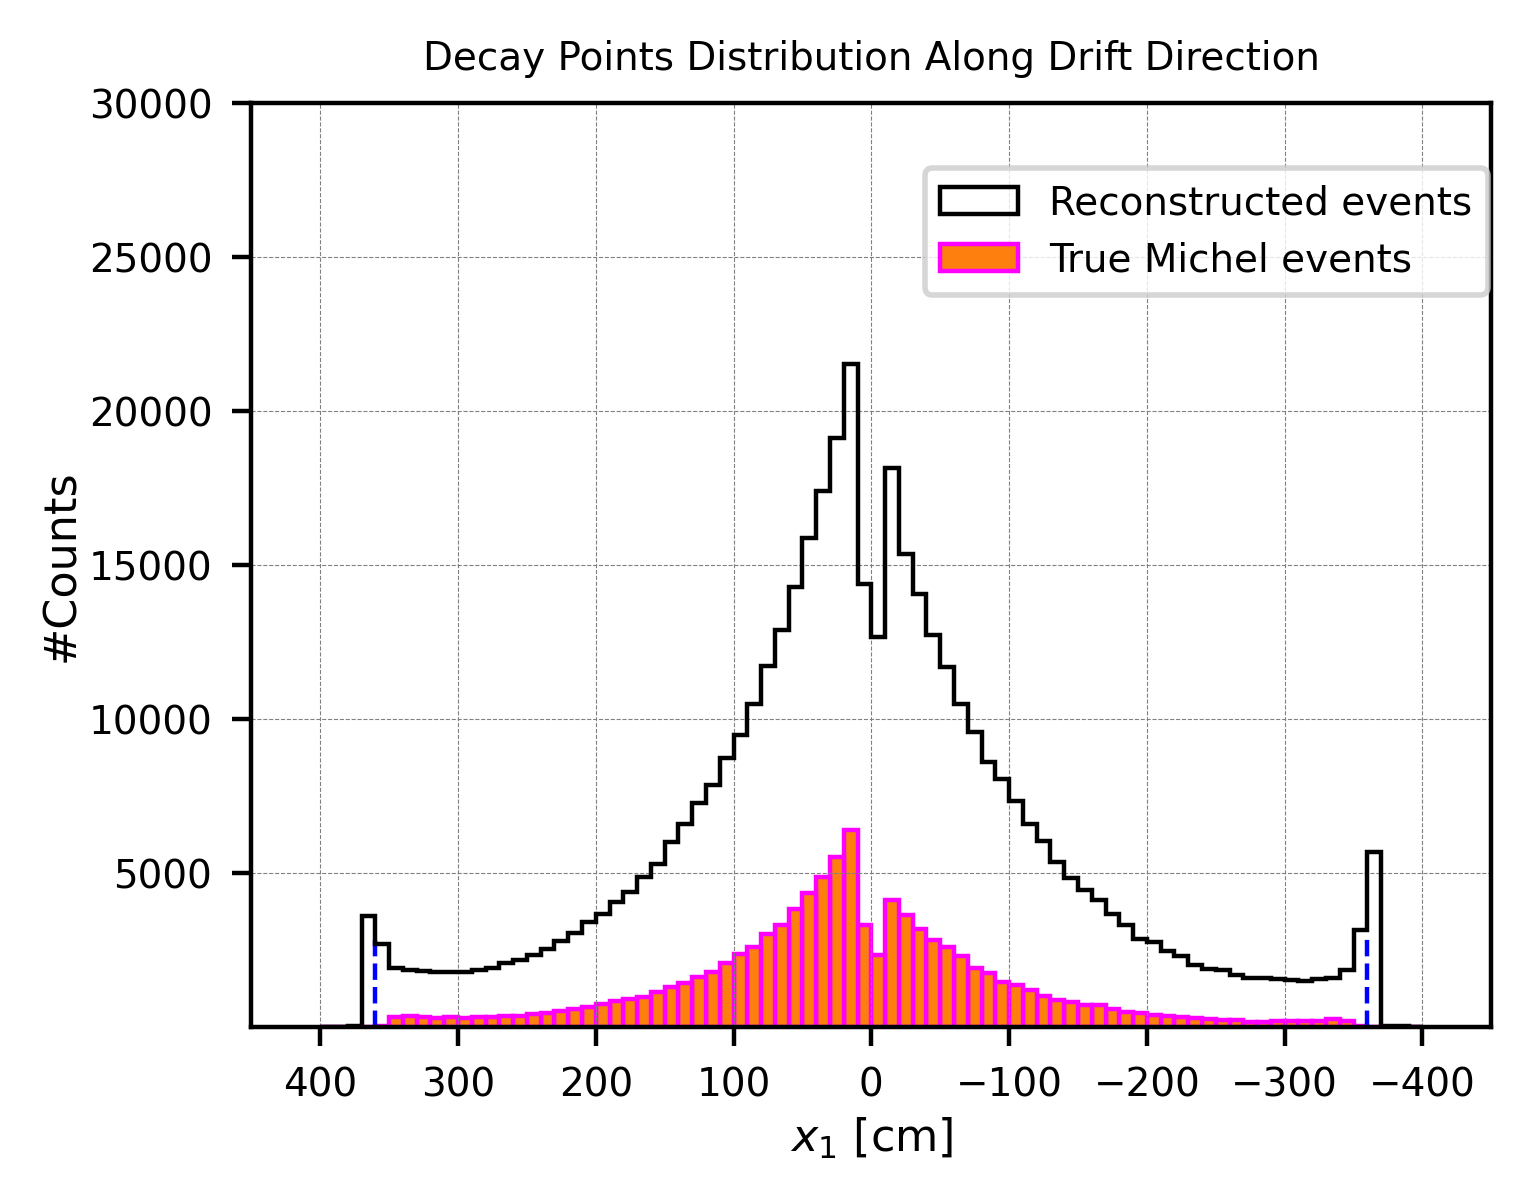

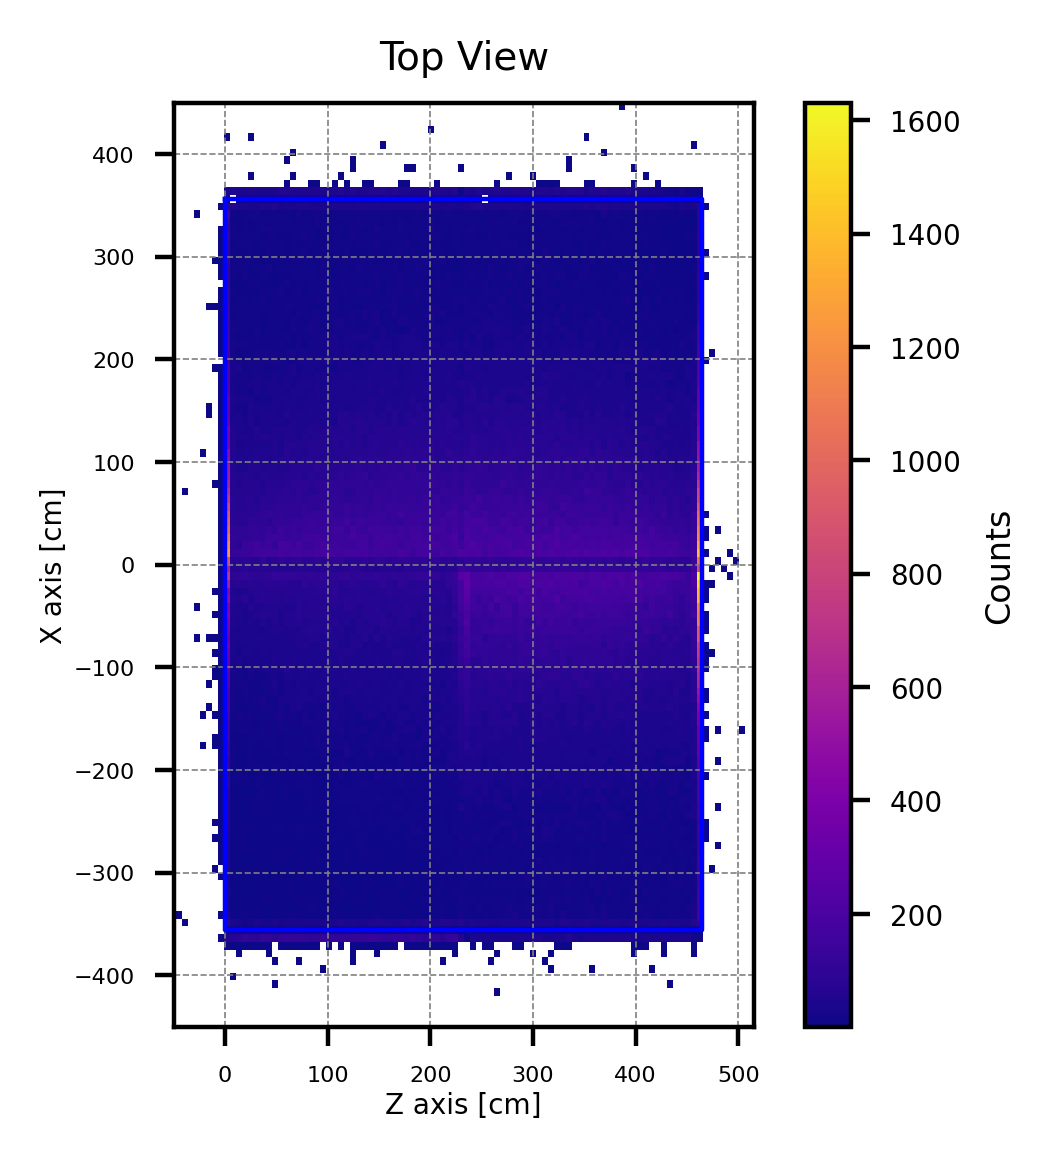

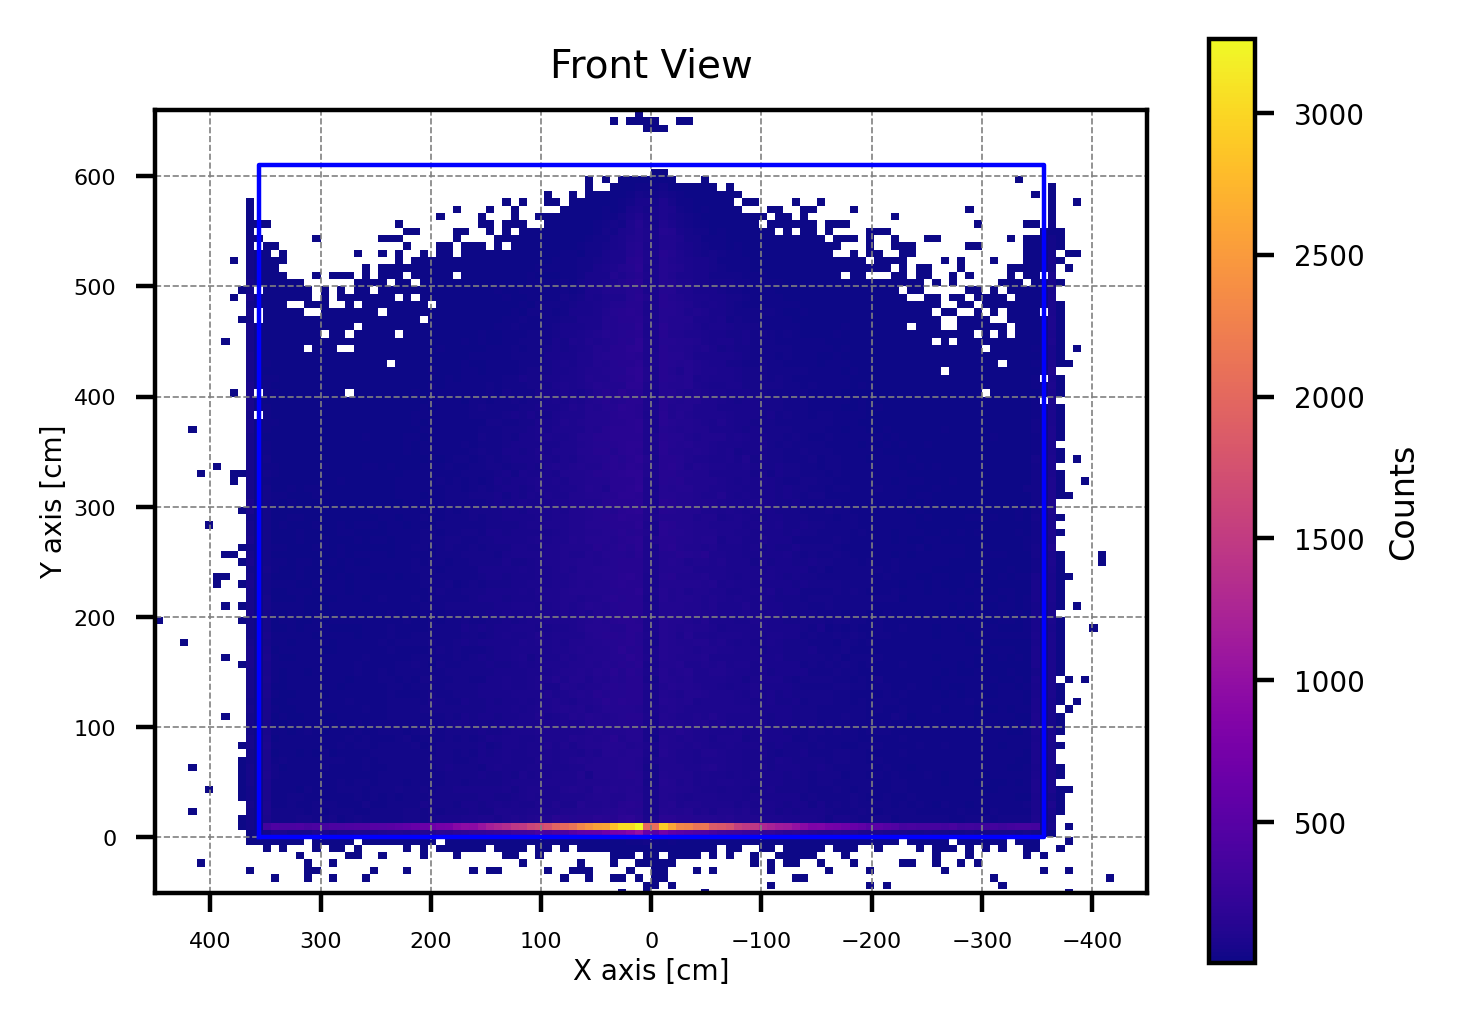

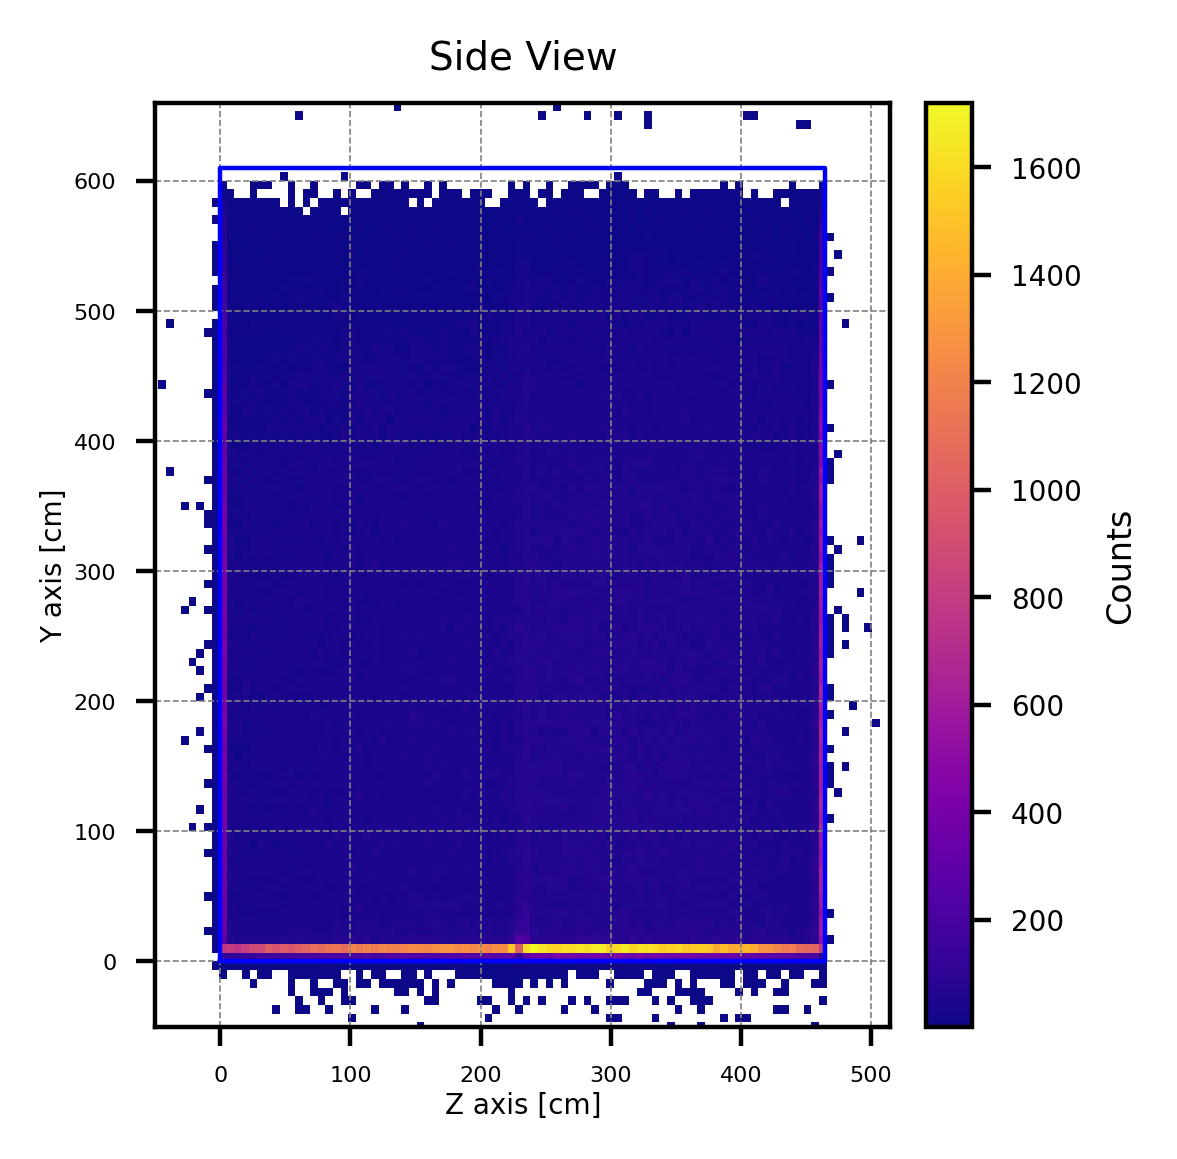

<Figure size 1600x1200 with 0 Axes>

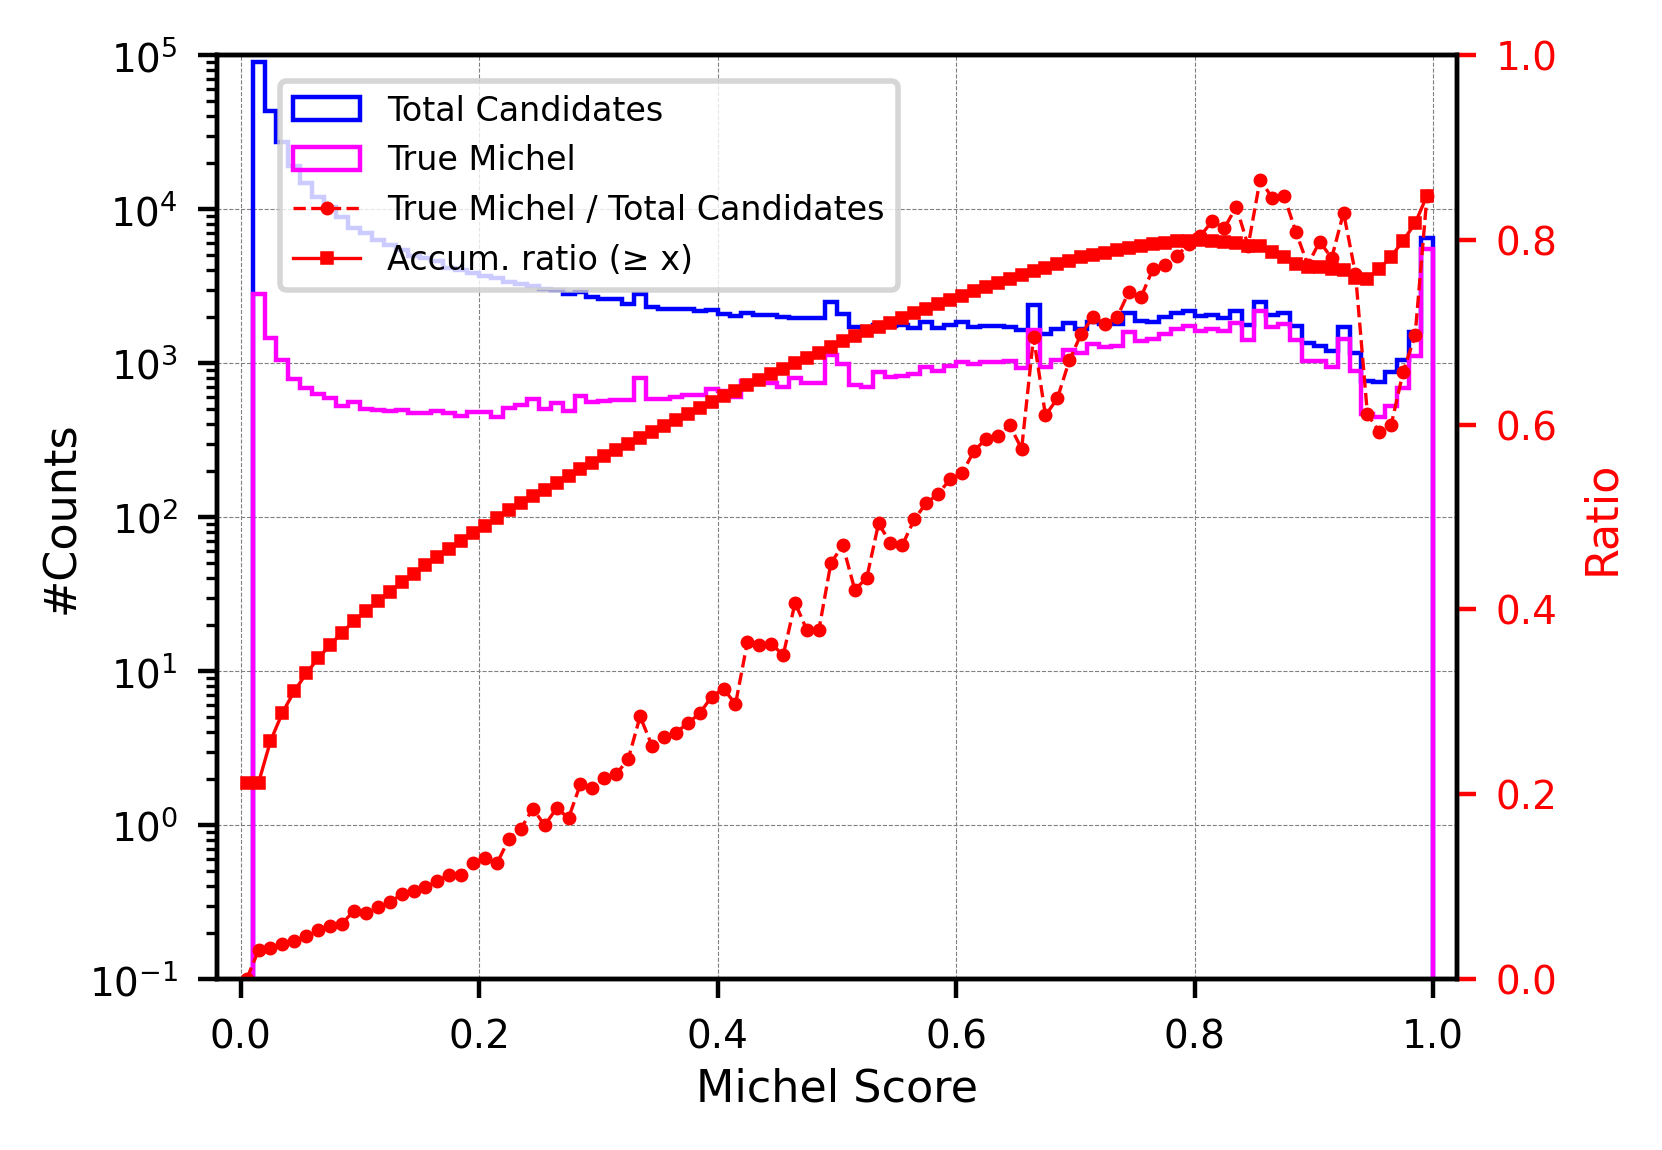

<Figure size 1600x1200 with 0 Axes>

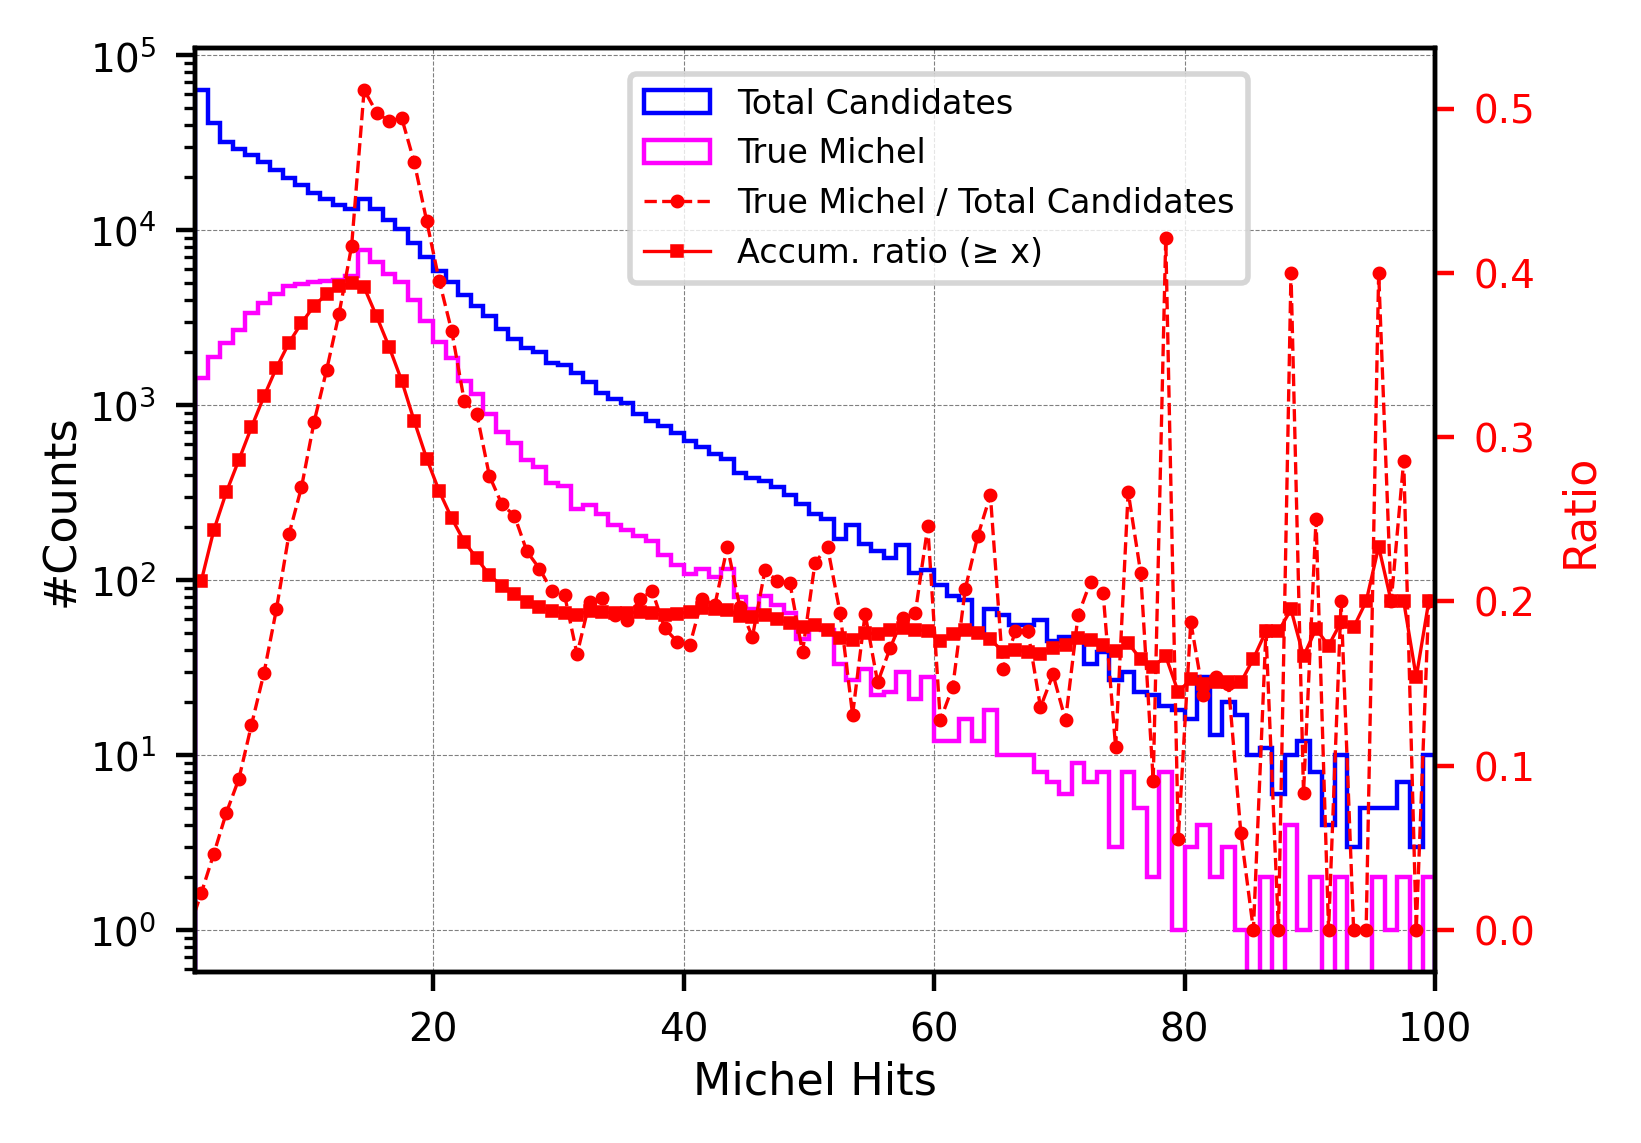

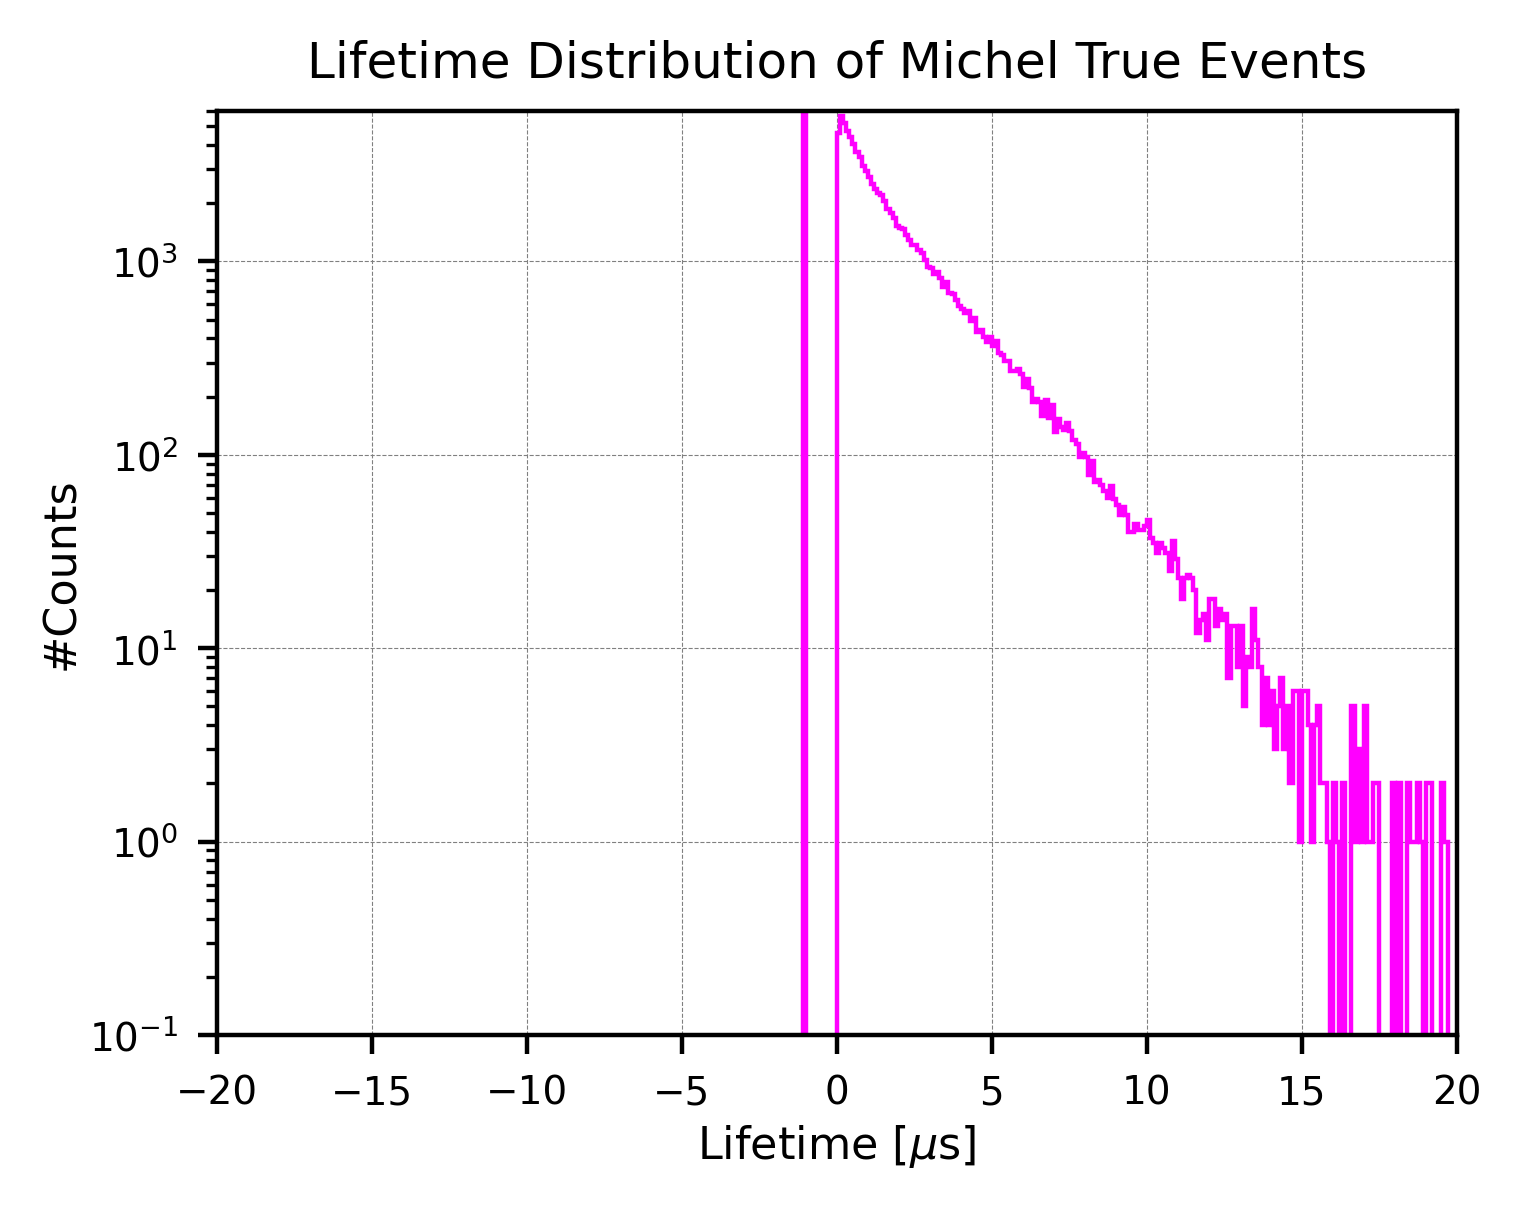

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]
vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]
vals_lifetime_initial = [ev.lifetime_initial for ev in events_reco]

vals_decayX_true = [ev.decayX_initial for ev in events_true]
vals_MS_true = [ev.MS_initial for ev in events_true]
vals_MH_true = [ev.MH_initial for ev in events_true]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 30000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(0.1, 100000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.00)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})


plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.6, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-20, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()









<br />
<br />
<br />

## Explore True Michel distribution:

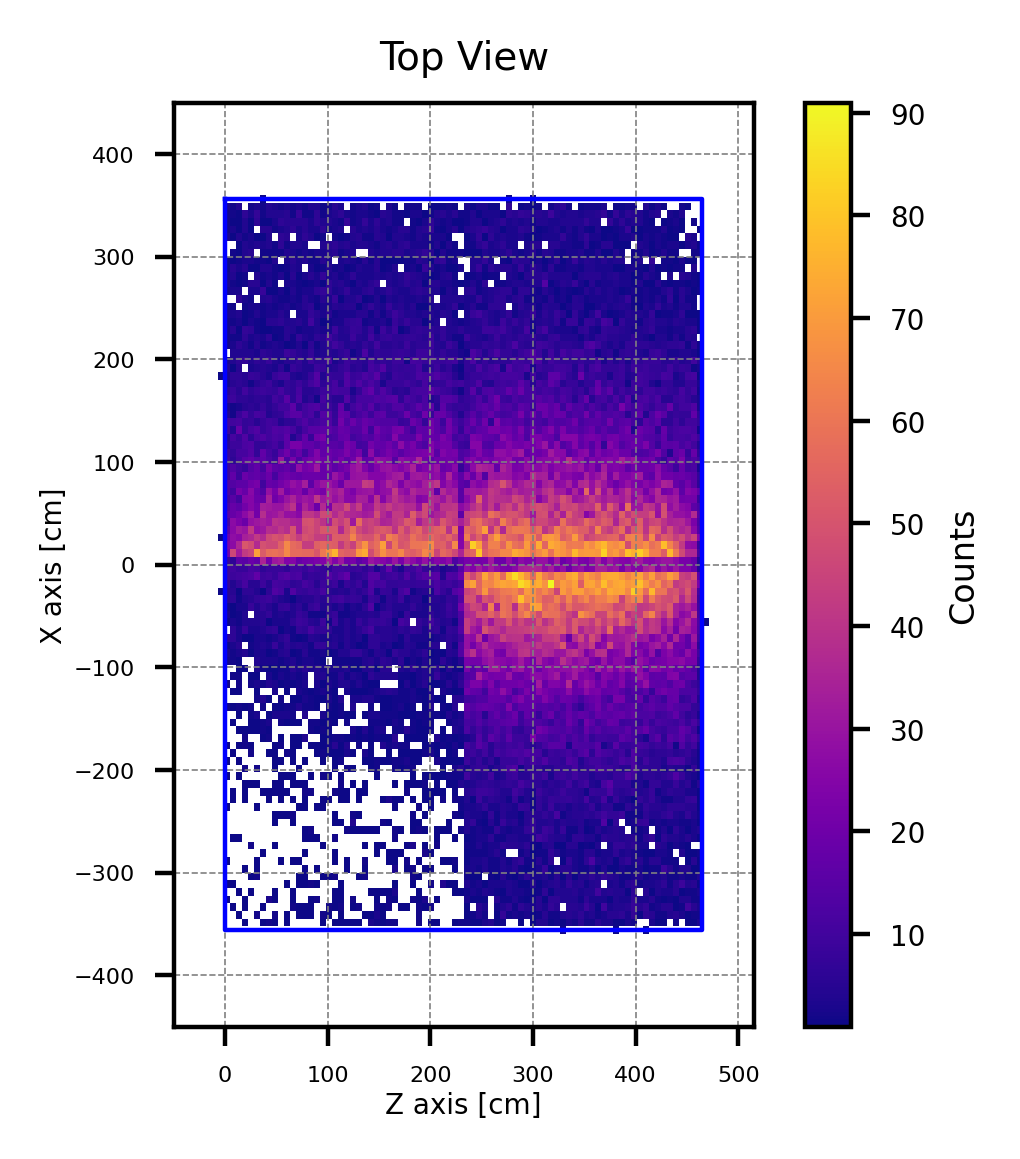

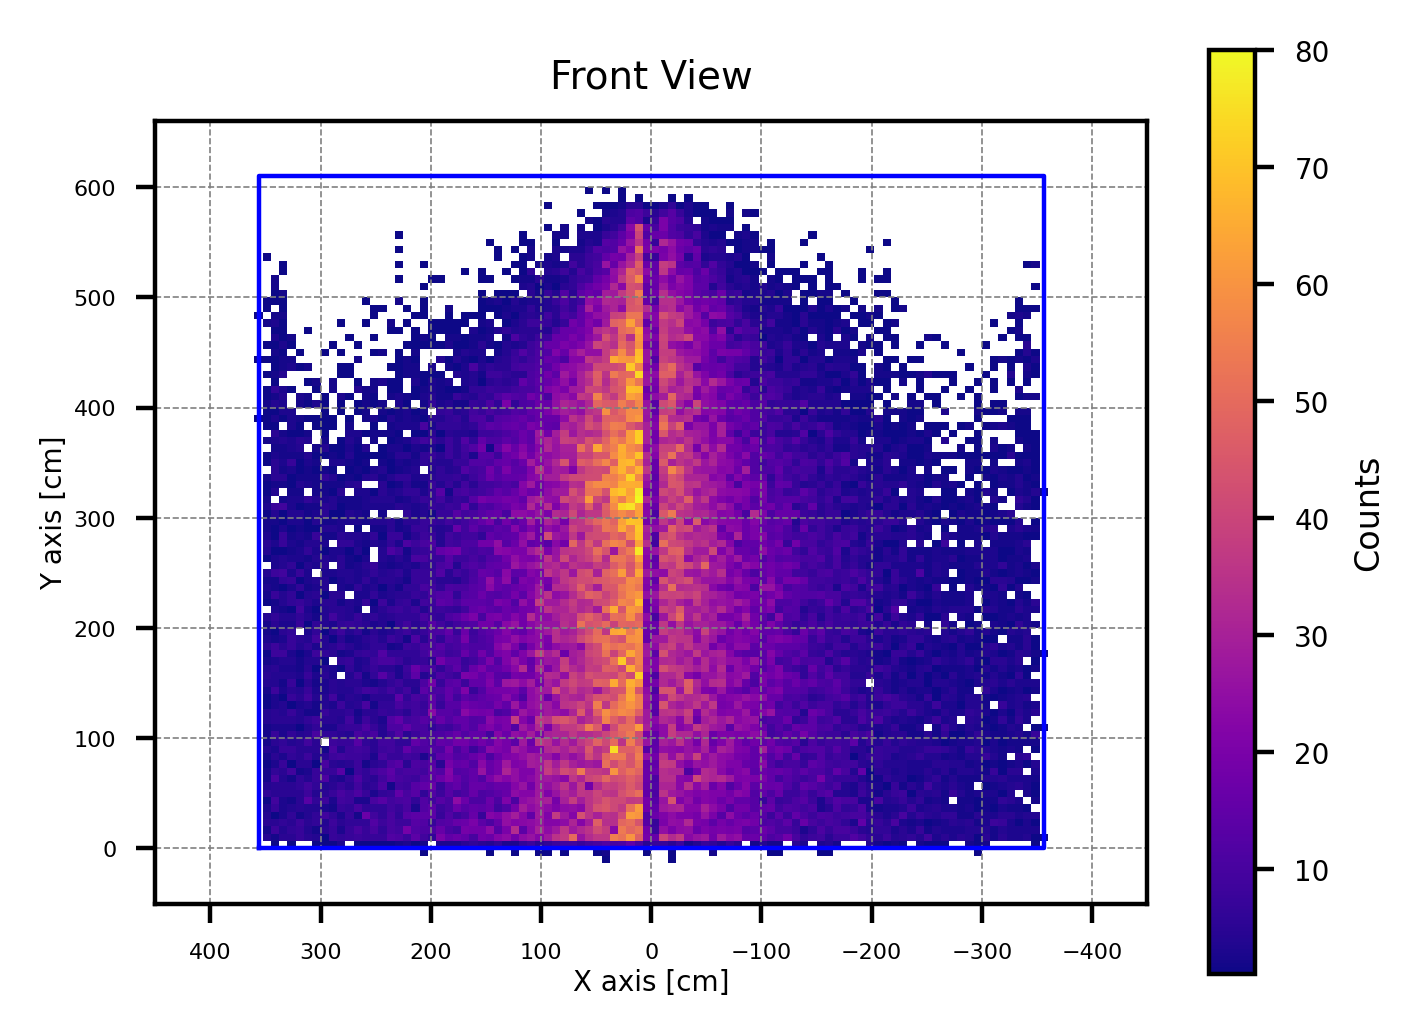

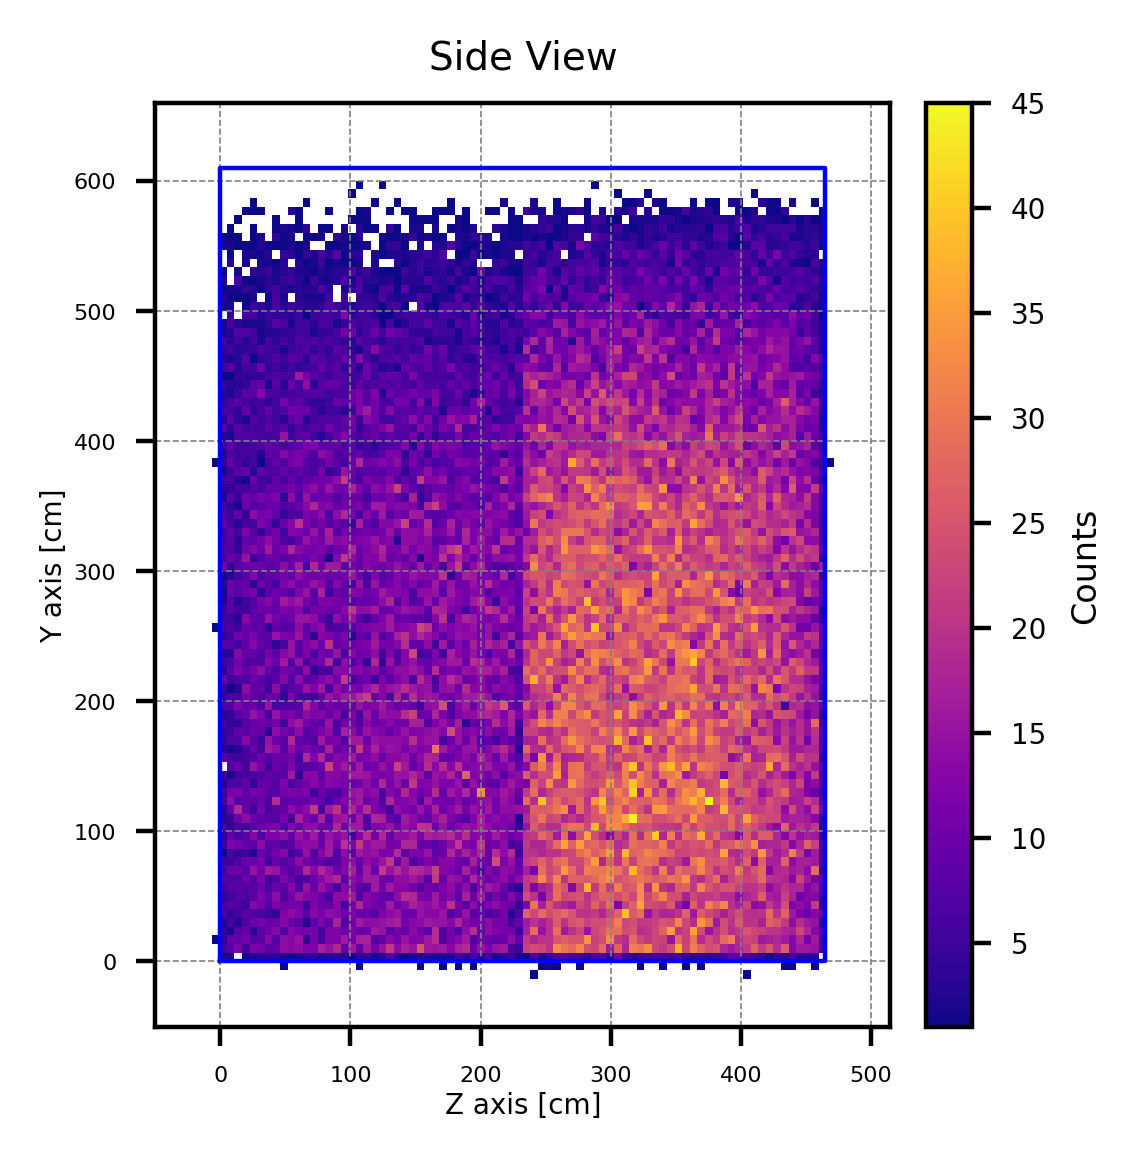

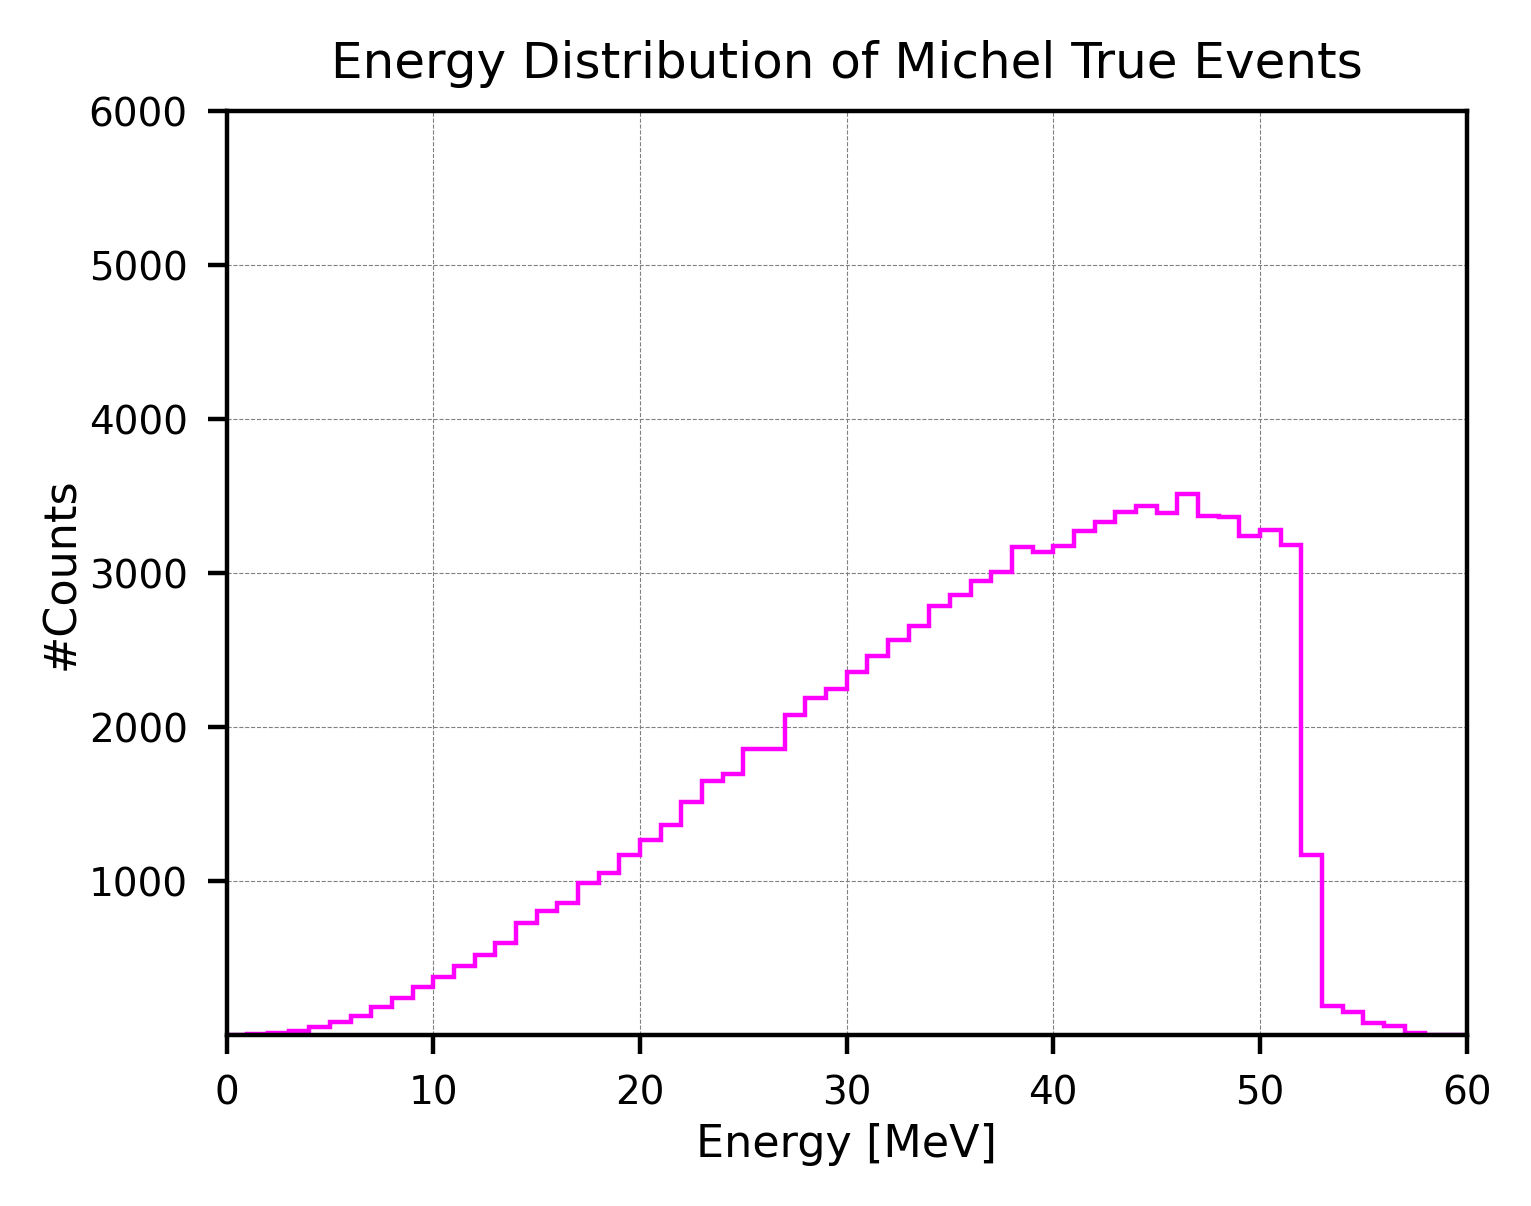

In [4]:
 
vals_decayY_true = [ev.decayY_initial for ev in events_true]
vals_decayZ_true = [ev.decayZ_initial for ev in events_true]
vals_energy_true = [ev.energy_initial for ev in events_true]


#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayX_true, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_true, vals_decayY_true, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayY_true, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 6000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  




### True lifetime fitting:


Michel e^+:  79078 / 451453 (17.52%)
Michel e^-:  16847 / 451453 (3.73%)
False     :  0 / 451453 (0.00%)

#e^+ / #e^-:  79078 / 16847 (4.69)


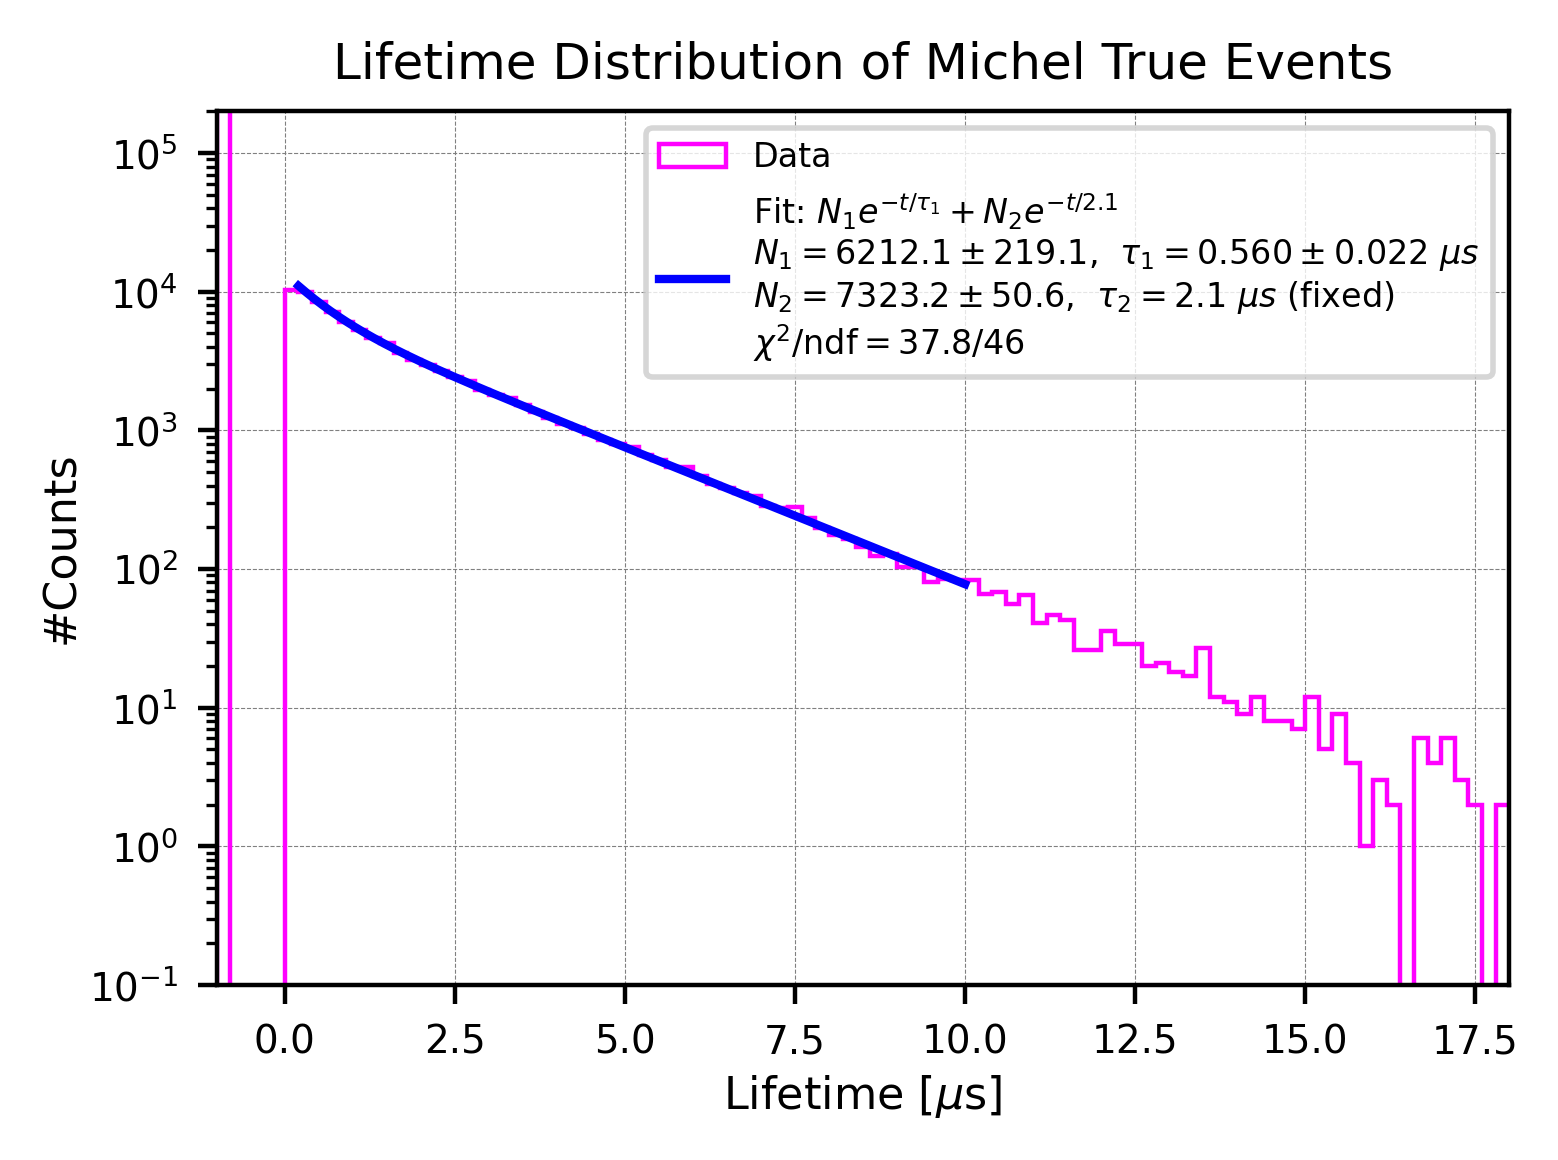

N1 = 6212.137 ± 219.082
tau1 = 0.55950 ± 0.02212 us
N2 = 7323.234 ± 50.569
chi2/ndf = 37.81/46 = 0.822


/Users/shuaixiangzhang/miniconda3/envs/cern_root/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


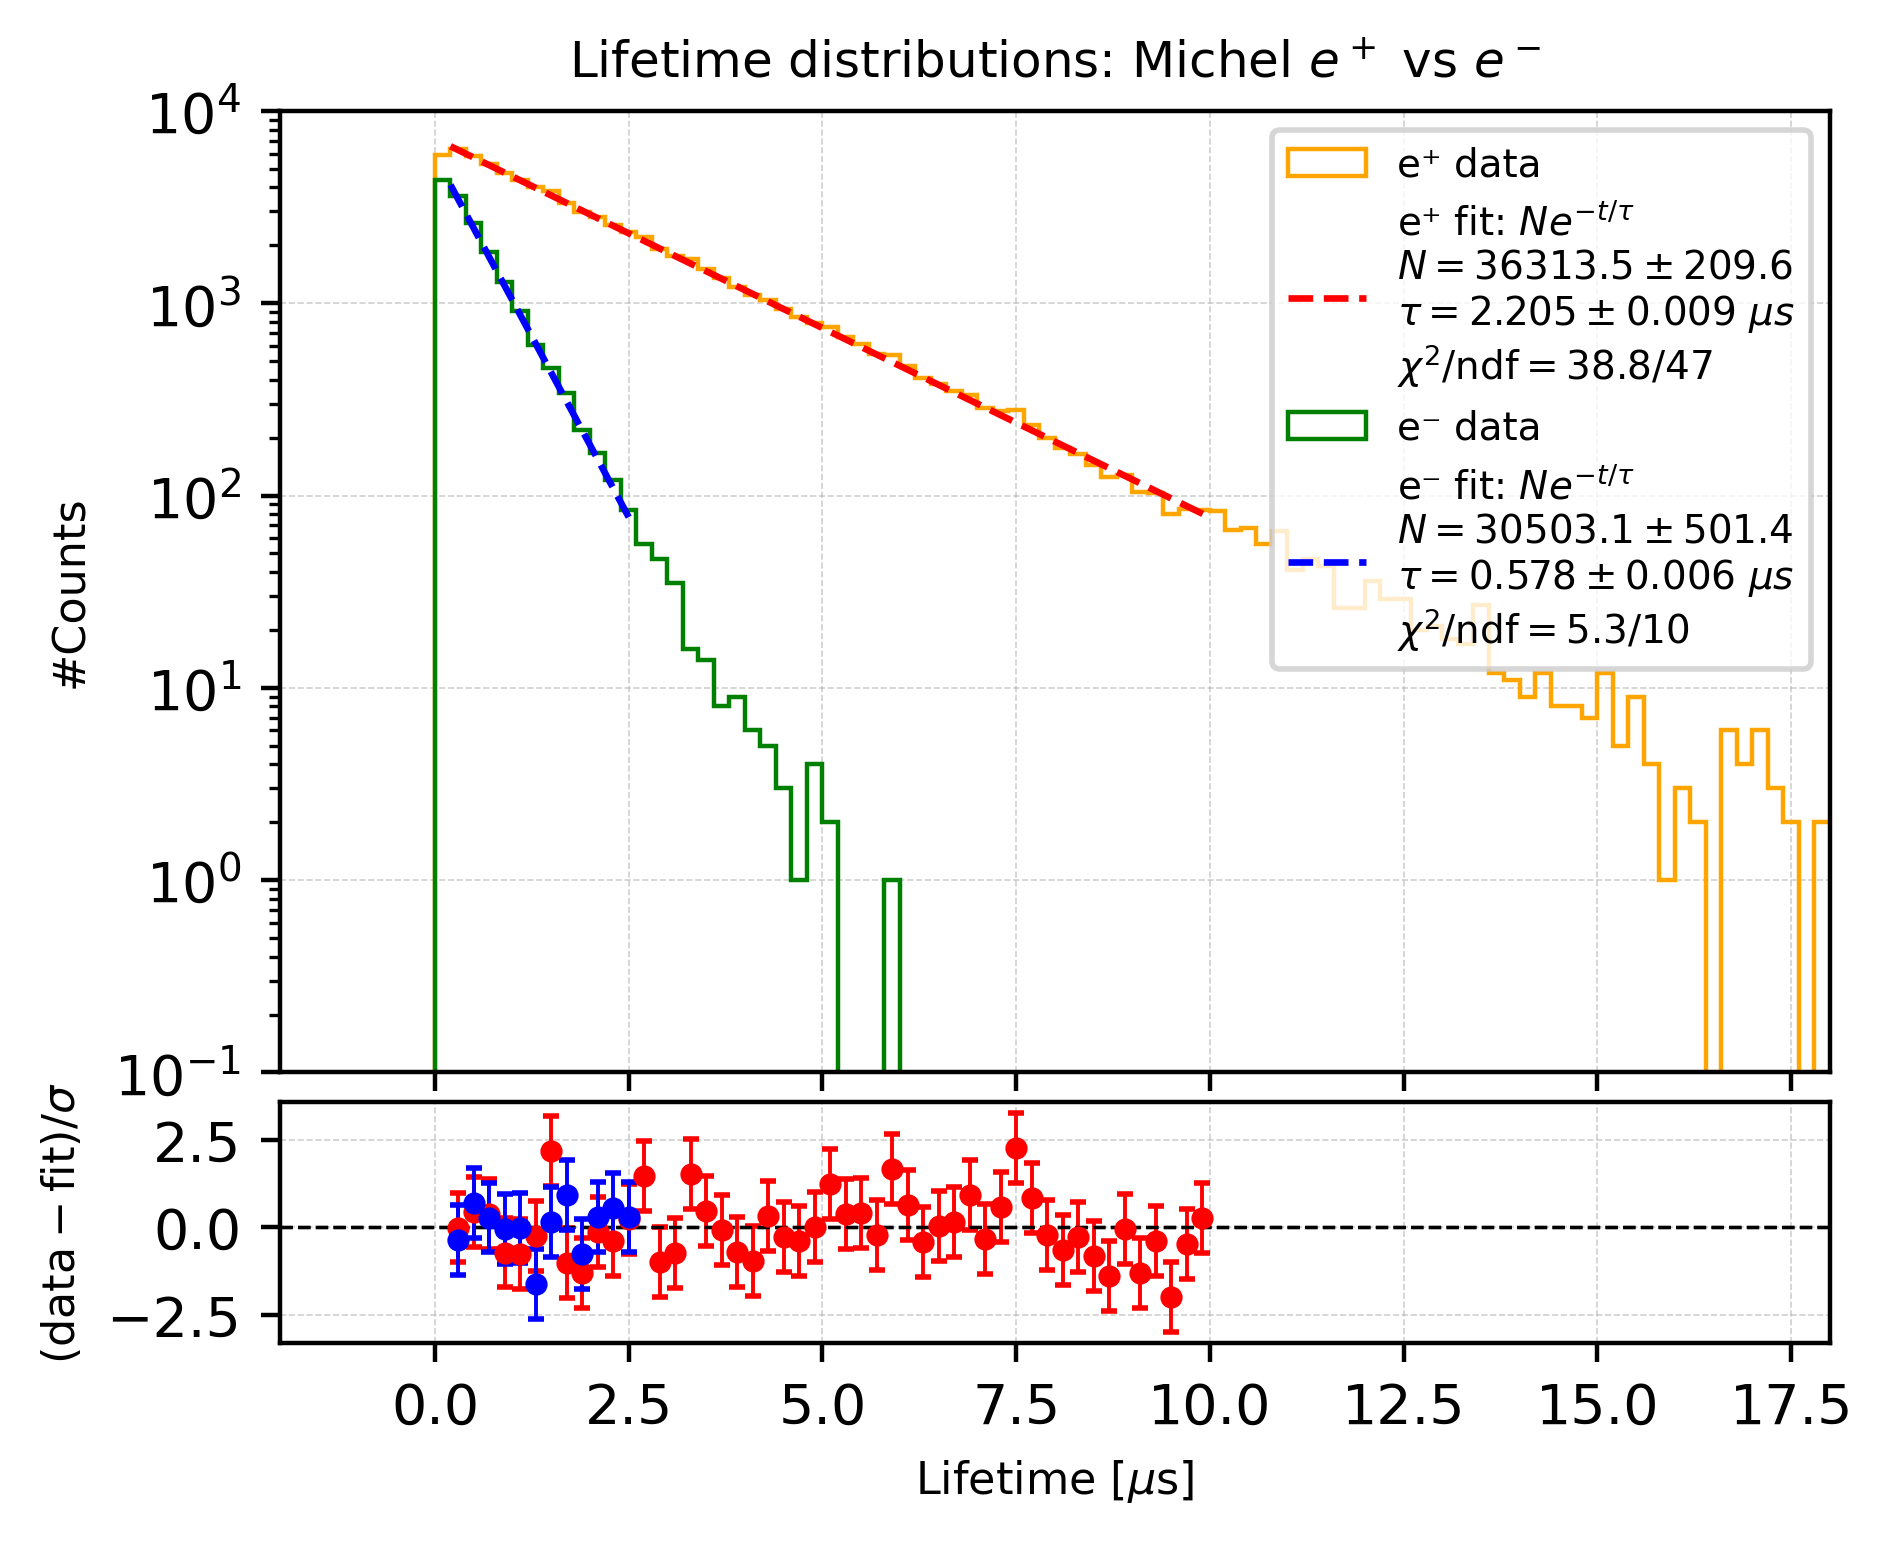

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit




# Seperate Michel e^- and e^+------------------------------
life_pM = []
life_nM = []
count_0= 0

for i in range(0, len(events_true)):
    pdg = events_true[i].pdg_initial
    life = events_true[i].lifetime_initial

    if pdg < 0:
        life_pM.append(life)
    elif pdg > 0:
        life_nM.append(life)
    elif pdg == 0:
        count_0 += 1


print("\nMichel e^+: ", len(life_pM), "/", len(pdg_initial), "({:.2f}%)".format(len(life_pM)/len(pdg_initial)*100))
print("Michel e^-: ", len(life_nM), "/", len(pdg_initial), "({:.2f}%)".format(len(life_nM)/len(pdg_initial)*100))
print("False     : ", count_0, "/", len(pdg_initial), "({:.2f}%)".format(count_0/len(pdg_initial)*100))

print("\n#e^+ / #e^-: ", len(life_pM), "/", len(life_nM), 
      "({:.2f})".format(len(life_pM)/len(life_nM)))




# Define the new exponential decay function=======================================================
# -------------------------
# Model: N1*exp(-t/tau1) + N2*exp(-t/2.2)  (tau2 fixed)
# -------------------------
def exp_decay(t, N1, tau1, N2):
    return N1 * np.exp(-t / tau1) + N2 * np.exp(-t / 2.2)

# Settings for the histogram
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.2
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Histogram the data
counts, bin_edges = np.histogram(lifetime_initial, bins=bins, range=(range_min, range_max))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


# Select data within the fitting range
fit_mask = (bin_centers >= 0.2) & (bin_centers <= 10)
x_fit_all = bin_centers[fit_mask]
y_fit_all = counts[fit_mask]

# --- Skip zero bins (avoid infinite weight from 1/sigma^2 with sigma=sqrt(y)) ---
nz = y_fit_all > 0
x_fit = x_fit_all[nz]
y_fit = y_fit_all[nz]
sigma = np.sqrt(y_fit)  # Poisson uncertainty per bin

# Initial guesses (safe)
N1_0 = float(np.max(y_fit)) if y_fit.size else 1.0
tau1_0 = 2.0
N2_0 = max(N1_0 / 10.0, 1.0)

# Weighted least squares fit (absolute_sigma=True → covariance reflects our sigmas)
popt, pcov = curve_fit(
    exp_decay, x_fit, y_fit,
    p0=[N1_0, tau1_0, N2_0],
    sigma=sigma,
    absolute_sigma=True,
    bounds=([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf]),
    maxfev=20000,
)
N1_fit, tau1_fit, N2_fit = popt
perr = np.sqrt(np.diag(pcov))  # 1σ uncertainties
N1_err, tau1_err, N2_err = perr

# Compute chi-squared with provided sigmas
y_exp = exp_decay(x_fit, *popt)
residual = (y_fit - y_exp) / sigma
chi2 = np.sum(residual**2)
ndf = max(len(x_fit) - len(popt), 1)
chi2_ndf = chi2 / ndf


# Smooth curve for plotting
x_smooth = np.linspace(0.2, 10, 500)
y_smooth = exp_decay(x_smooth, *popt)

# Plot histogram (data)
plt.hist(lifetime_initial, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8, label="Data")

# Plot the weighted-χ² fit
plt.plot(
    x_smooth, y_smooth, 'b-',
    label=(
        r'Fit: $N_1 e^{-t/\tau_1} + N_2 e^{-t/2.1}$' + '\n'
        + rf'$N_1={N1_fit:.1f}\pm{N1_err:.1f}$,  $\tau_1={tau1_fit:.3f}\pm{tau1_err:.3f}\ \mu s$' + '\n'
        + rf'$N_2={N2_fit:.1f}\pm{N2_err:.1f}$,  $\tau_2=2.1\ \mu s$ (fixed)' + '\n'
        + rf'$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$'
    )
)

# Final plot settings (your style)
plt.xlim(-1, 18)
plt.ylim(0.1, 200000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()

# Optional: also print to console
print(
    f"N1 = {N1_fit:.3f} ± {N1_err:.3f}\n"
    f"tau1 = {tau1_fit:.5f} ± {tau1_err:.5f} us\n"
    f"N2 = {N2_fit:.3f} ± {N2_err:.3f}\n"
    f"chi2/ndf = {chi2:.2f}/{ndf} = {chi2_ndf:.3f}"
)









#Fitting seperating for Michel e^+ and e^-=========================================
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

# --- bin-integrated exponential model ---
def exp1_integrated(bin_edges, N, tau):
    """
    Predict counts in each bin [a,b] using the integral of N*exp(-t/tau).
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    return N * tau * (np.exp(-a/tau) - np.exp(-b/tau))

# --- fitting helper (χ² least squares with bin integration) ---
def fit_and_draw(ax, ax_resid, sample, label_prefix, fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red"):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # fit window mask
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m]
    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]  # edges covering fit window

    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8,
                label=f"{label_prefix} data", color=hist_color)
        return None

    sigma = np.sqrt(np.maximum(y, 1.0))

    # fit using integrated model
    N0, tau0 = np.sum(y), 2.0
    popt, pcov = curve_fit(
        lambda edges, N, tau: exp1_integrated(edges, N, tau),
        edges_fit, y,
        p0=[N0, tau0], sigma=sigma, absolute_sigma=True,
        bounds=([0, 1e-6], [np.inf, np.inf]), maxfev=20000
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi²/ndf
    y_model = exp1_integrated(edges_fit, *popt)
    pulls = (y - y_model) / sigma
    chi2 = np.sum(pulls**2)
    ndf = len(y) - len(popt)

    # smooth fit curve (Option B: scaled PDF)
    N_tot = np.sum(counts)   # total entries in histogram
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_tot/tau_fit) * np.exp(-x_smooth/tau_fit) * bin_width

    # draw histogram
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8,
            label=f"{label_prefix} data", color=hist_color)

    # draw smooth fit curve
    ax.plot(x_smooth, y_smooth,
            label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
                   + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
                   + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"),
            color=fit_color, linestyle="--", linewidth=1.2)

    # residuals (pulls)
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    bin_centers_fit = 0.5 * (edges_fit[:-1] + edges_fit[1:])
    ax_resid.errorbar(bin_centers_fit, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    return tau_fit, tau_err, chi2, ndf


# ----------------------------------------------------
# Plot with residuals panel
# ----------------------------------------------------
bin_width = 0.2
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit e+ (orange hist, red fit) and e- (green hist, blue fit)
fit_and_draw(ax, ax_resid, np.asarray(life_pM), "e⁺",
             fit_range=(0.2, 10.0), hist_color="orange", fit_color="red")
fit_and_draw(ax, ax_resid, np.asarray(life_nM), "e⁻",
             fit_range=(0.2, 2.5), hist_color="green", fit_color="blue")

# Style top plot
ax.set_ylim(0.1, 10000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
ax.set_title("Lifetime distributions: Michel $e^+$ vs $e^-$", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# Style residuals
ax_resid.set_xlim(-2, 18)
ax_resid.set_xlabel("Lifetime [$\mu$s]", fontsize=8)
#ax_resid.set_ylabel("Pulls", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()






<br />
<br />
<br />
<br />

### Bin-integrated fittings: (Best)

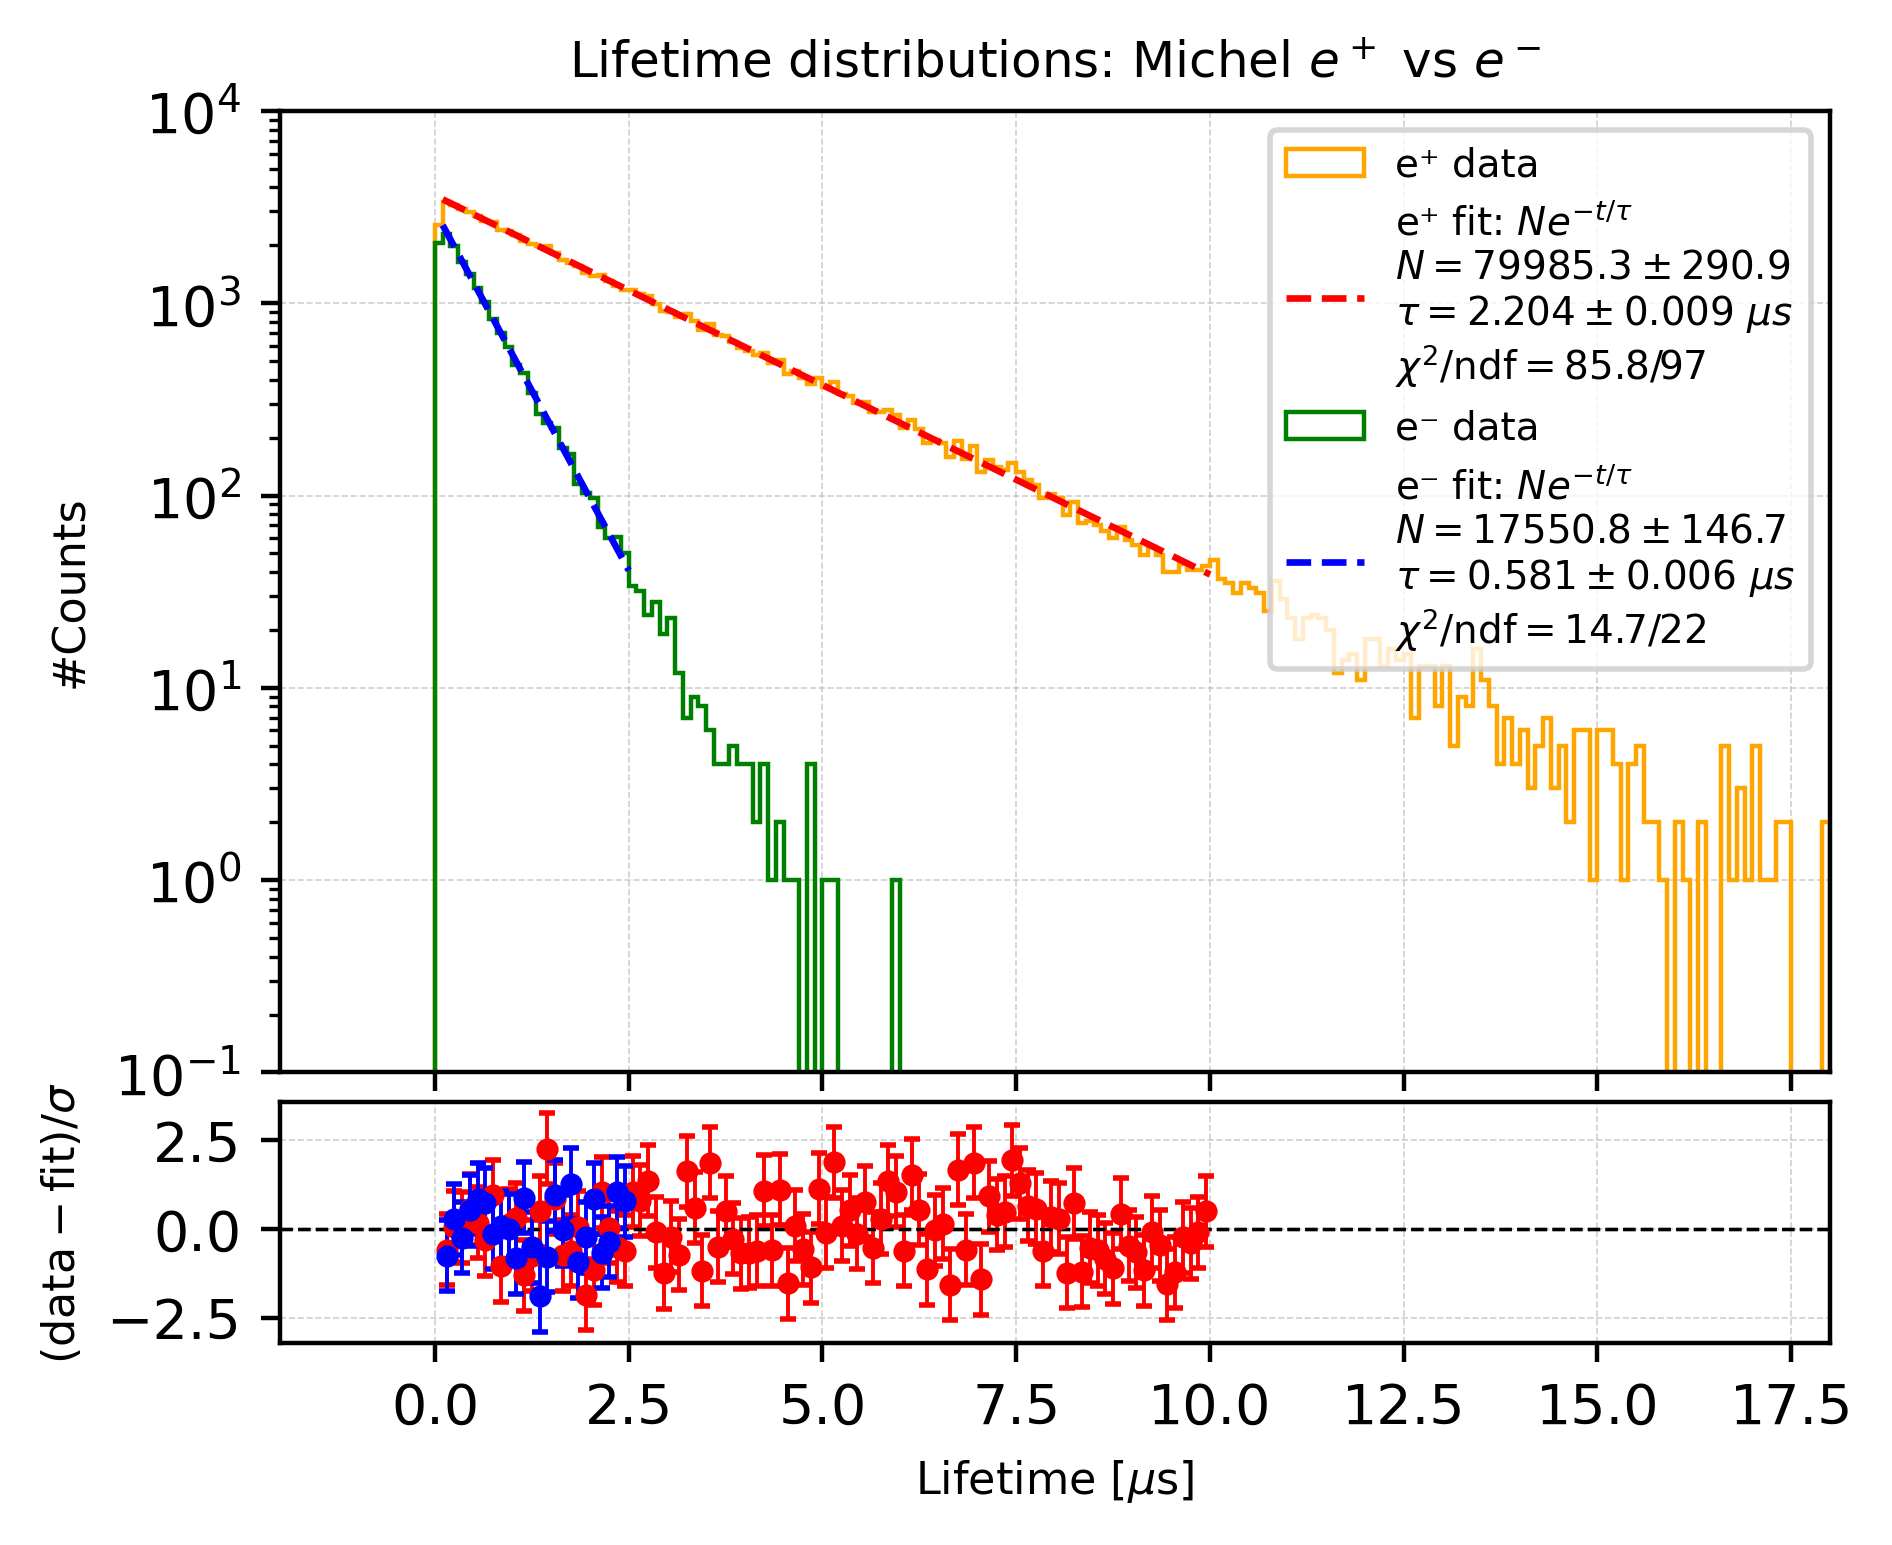

In [7]:
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt

# --- single exponential model: bin-integrated ---
def exp1_integrated(bin_edges, N, tau):
    """
    Expected counts per bin = integral over each bin.
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    return N * (np.exp(-a / tau) - np.exp(-b / tau))

# --- fitting helper (χ² least squares with integrated model) ---
def fit_and_draw(ax, ax_resid, sample, label_prefix, fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red"):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # fit window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    x = centers[m]
    y = counts[m]
    edges_fit = bin_edges[m.nonzero()[0][0]: m.nonzero()[0][-1] + 2]  # edges spanning chosen bins

    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, label=f"{label_prefix} data", color=hist_color)
        return None

    sigma = np.sqrt(np.maximum(y, 1.0))

    # fit using integrated model
    N0, tau0 = float(np.sum(y)), 2.0
    popt, pcov = curve_fit(
        lambda edges, N, tau: exp1_integrated(edges, N, tau),
        edges_fit, y,
        p0=[N0, tau0],
        sigma=sigma, absolute_sigma=True,
        bounds=([0, 1e-6], [np.inf, np.inf])
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi²/ndf
    y_model = exp1_integrated(edges_fit, *popt)
    pulls = (y - y_model) / sigma
    chi2 = np.sum(pulls**2)
    ndf = len(y) - len(popt)

    # smooth fit curve (draw continuous line for visualization)
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_fit / tau_fit) * np.exp(-x_smooth / tau_fit) * (bin_width)  # for plotting

    # draw hist (data)
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, label=f"{label_prefix} data", color=hist_color)

    # draw fit curve
    ax.plot(x_smooth, y_smooth,
            label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
                   + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
                   + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"),
            color=fit_color, linestyle="--", linewidth=1.2)

    # residuals (pulls)
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    return tau_fit, tau_err, chi2, ndf


# ----------------------------------------------------
# Plot with residuals panel
# ----------------------------------------------------
bin_width = 0.1
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit e+ (orange hist, red fit) and e- (green hist, blue fit)
fit_and_draw(ax, ax_resid, np.asarray(life_pM), "e⁺",
             fit_range=(0.1, 10.0), hist_color="orange", fit_color="red")
fit_and_draw(ax, ax_resid, np.asarray(life_nM), "e⁻",
             fit_range=(0.1, 2.5), hist_color="green", fit_color="blue")

# Style top plot
ax.set_ylim(0.1, 10000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
ax.set_title("Lifetime distributions: Michel $e^+$ vs $e^-$", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# Style residuals
ax_resid.set_xlim(-2, 18)
ax_resid.set_xlabel("Lifetime [$\mu$s]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()


#### Unbinned maximum likelihood fit (not ideal):

e⁺: τ = 2.2362 ± 0.0080 μs (unbinned MLE)
e⁻: τ = 0.6069 ± 0.0047 μs (unbinned MLE)


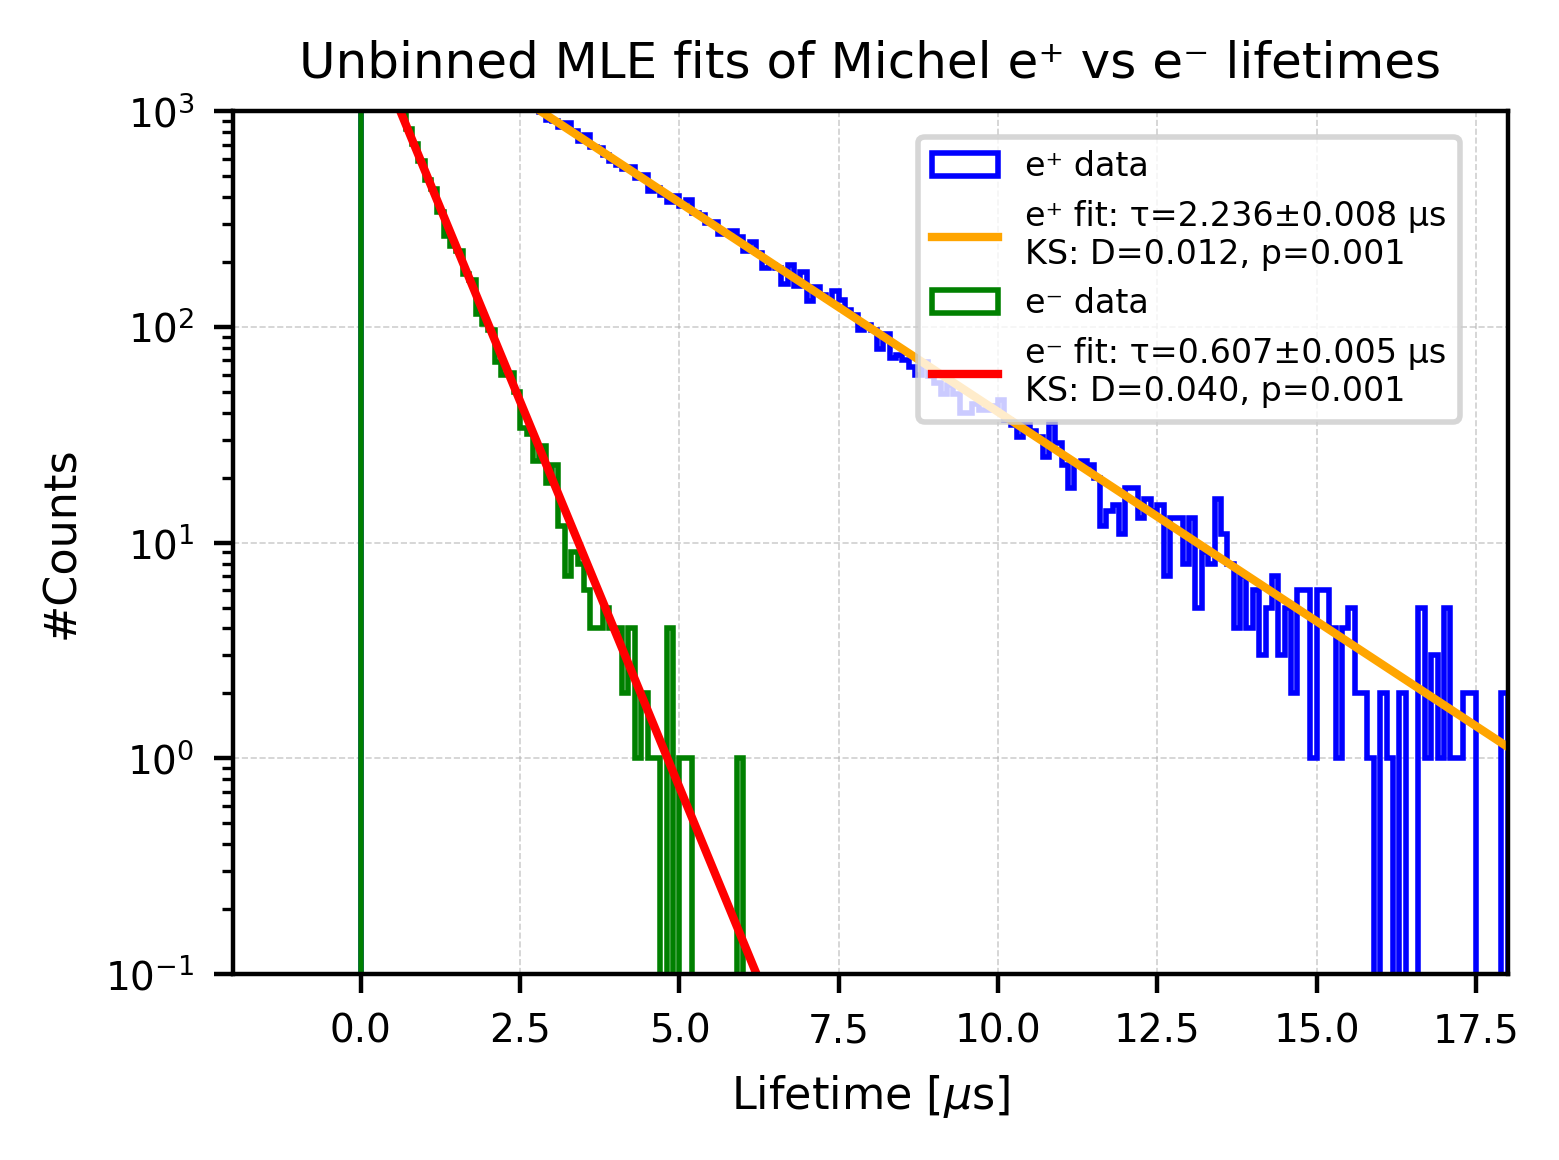

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -----------------------------------------------------
# Negative log-likelihood for exponential
# -----------------------------------------------------
def neg_log_likelihood(tau, data):
    if tau <= 0:
        return np.inf
    n = len(data)
    return n * np.log(tau) + np.sum(data) / tau

def fit_unbinned(data, label):
    # Minimize NLL
    res = minimize(lambda x: neg_log_likelihood(x[0], data),
                   x0=[np.mean(data)],  # initial guess = sample mean
                   bounds=[(1e-6, None)])
    tau_hat = res.x[0]

    # Error estimate from curvature (second derivative)
    n = len(data)
    sigma_tau = tau_hat / np.sqrt(n)

    print(f"{label}: τ = {tau_hat:.4f} ± {sigma_tau:.4f} μs (unbinned MLE)")
    return tau_hat, sigma_tau

# -----------------------------------------------------
# KS with parametric bootstrap
# -----------------------------------------------------
def ks_expon_bootstrap(data, B=1000, rng=123, tmin=None, tmax=None):
    """
    KS GOF test for Exp(tau) with tau fitted from the data.
    Returns (D_obs, p_boot). Handles optional truncation [tmin, tmax].
    """
    x = np.asarray(data, dtype=float)
    if tmin is not None:
        x = x[x >= tmin]
    else:
        tmin = 0.0
        x = x[x >= 0]
    if tmax is not None:
        x = x[x <= tmax]

    N = len(x)
    if N < 5:
        return np.nan, np.nan

    # truncated exponential CDF
    def cdf_truncexpon(t, tau):
        a = np.exp(-tmin/tau)
        b = np.exp(-(tmax/tau)) if tmax is not None else 0.0
        num = a - np.exp(-t/tau)
        den = a - b
        return np.clip(num/den, 0.0, 1.0)

    # inverse CDF sampler
    def rvs_truncexpon(size, tau, rng):
        u = rng.random(size)
        a = np.exp(-tmin/tau)
        b = np.exp(-(tmax/tau)) if tmax is not None else 0.0
        return -tau * np.log(a - u*(a - b))

    # MLE tau (account for lower cut)
    tau_hat = np.mean(x - tmin)

    # KS statistic on observed data
    x_sorted = np.sort(x)
    Fn = np.arange(1, N+1)/N
    D_obs = np.max(np.abs(Fn - cdf_truncexpon(x_sorted, tau_hat)))

    # bootstrap
    rng = np.random.default_rng(rng)
    count_ge = 0
    for _ in range(B):
        sim = rvs_truncexpon(N, tau_hat, rng)
        tau_b = np.mean(sim - tmin)
        sim_sorted = np.sort(sim)
        Fn_b = np.arange(1, N+1)/N
        D_b = np.max(np.abs(Fn_b - cdf_truncexpon(sim_sorted, tau_b)))
        if D_b >= D_obs:
            count_ge += 1

    p_boot = (count_ge + 1) / (B + 1)
    return float(D_obs), float(p_boot)

# -----------------------------------------------------
# Example: run fits
# -----------------------------------------------------
tau_p, dtau_p = fit_unbinned(np.asarray(life_pM), "e⁺")
tau_n, dtau_n = fit_unbinned(np.asarray(life_nM), "e⁻")

D_p, pval_p = ks_expon_bootstrap(np.asarray(life_pM), B=1000, rng=123)
D_n, pval_n = ks_expon_bootstrap(np.asarray(life_nM), B=1000, rng=123)

# -----------------------------------------------------
# Plot histogram with MLE overlay
# -----------------------------------------------------
plt.figure(figsize=(4,3), dpi=400)

bin_width = 0.1
bins = np.arange(0, 20, bin_width)

# e+
counts_p, edges_p, _ = plt.hist(life_pM, bins=bins, histtype='step',
                                color="blue", label="e⁺ data")
centers_p = 0.5*(edges_p[:-1] + edges_p[1:])
plt.plot(centers_p,
         len(life_pM) * (bin_width/tau_p) * np.exp(-centers_p/tau_p),
         color="orange",
         label=(fr"e⁺ fit: τ={tau_p:.3f}±{dtau_p:.3f} μs" + "\n"
                + fr"KS: D={D_p:.3f}, p={pval_p:.3f}"))

# e-
counts_n, edges_n, _ = plt.hist(life_nM, bins=bins, histtype='step',
                                color="green", label="e⁻ data")
centers_n = 0.5*(edges_n[:-1] + edges_n[1:])
plt.plot(centers_n,
         len(life_nM) * (bin_width/tau_n) * np.exp(-centers_n/tau_n),
         color="red",
         label=(fr"e⁻ fit: τ={tau_n:.3f}±{dtau_n:.3f} μs" + "\n"
                + fr"KS: D={D_n:.3f}, p={pval_n:.3f}"))

plt.xlim(-2, 18)
plt.ylim(0.1, 1000)
plt.yscale("log")
plt.xlabel('Lifetime [$\mu$s]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.title("Unbinned MLE fits of Michel e⁺ vs e⁻ lifetimes", fontsize=9)
plt.grid(linestyle="--", linewidth=0.3, alpha=0.6)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.99), fontsize=9, 
           markerscale=5, ncol=1, prop={'size': 6})

plt.tight_layout()
plt.show()


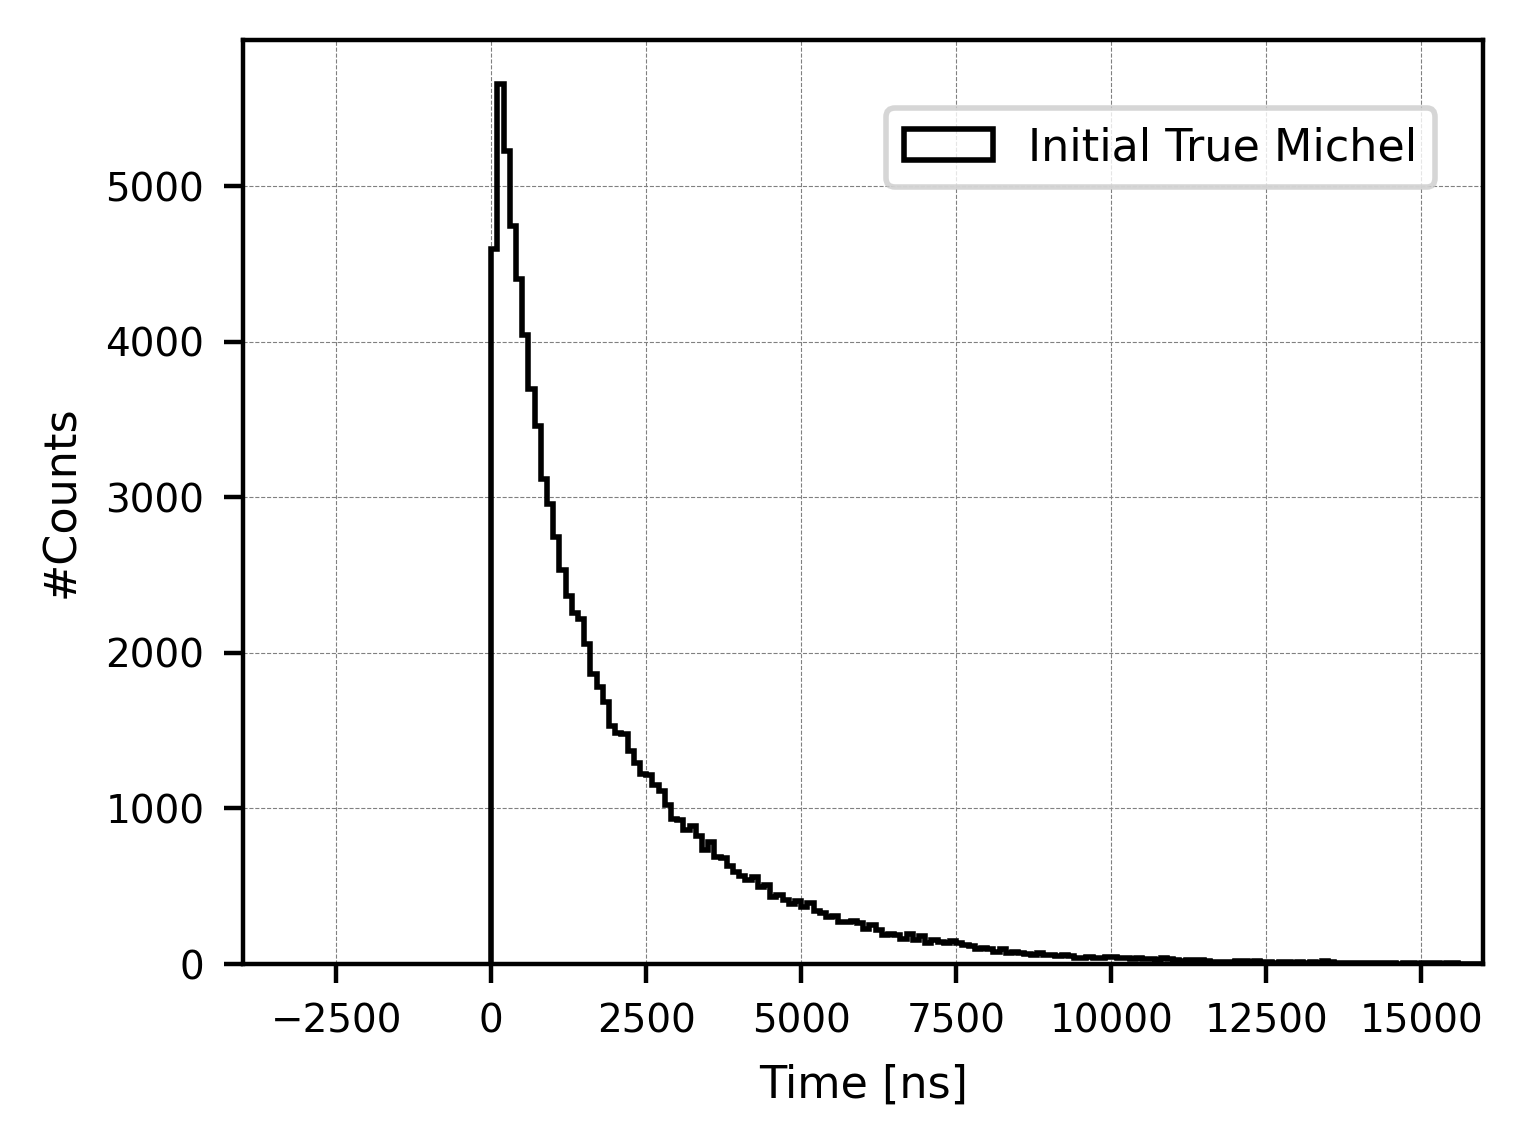

Center =       50 ns,  Count =   4596
Center =      150 ns,  Count =   5656
Center =      250 ns,  Count =   5224
Center =      350 ns,  Count =   4744
Center =      450 ns,  Count =   4403
Center =      550 ns,  Count =   4040
Center =      650 ns,  Count =   3696
Center =      750 ns,  Count =   3460
Center =      850 ns,  Count =   3118
Center =      950 ns,  Count =   2954
Center =     1050 ns,  Count =   2746
Center =     1150 ns,  Count =   2529
Center =     1250 ns,  Count =   2367
Center =     1350 ns,  Count =   2253
Center =     1450 ns,  Count =   2218
Center =     1550 ns,  Count =   2057
Center =     1650 ns,  Count =   1862
Center =     1750 ns,  Count =   1781
Center =     1850 ns,  Count =   1685
Center =     1950 ns,  Count =   1531
Center =     2050 ns,  Count =   1486
Center =     2150 ns,  Count =   1476
Center =     2250 ns,  Count =   1369
Center =     2350 ns,  Count =   1293
Center =     2450 ns,  Count =   1223
Center =     2550 ns,  Count =   1211
Center =    

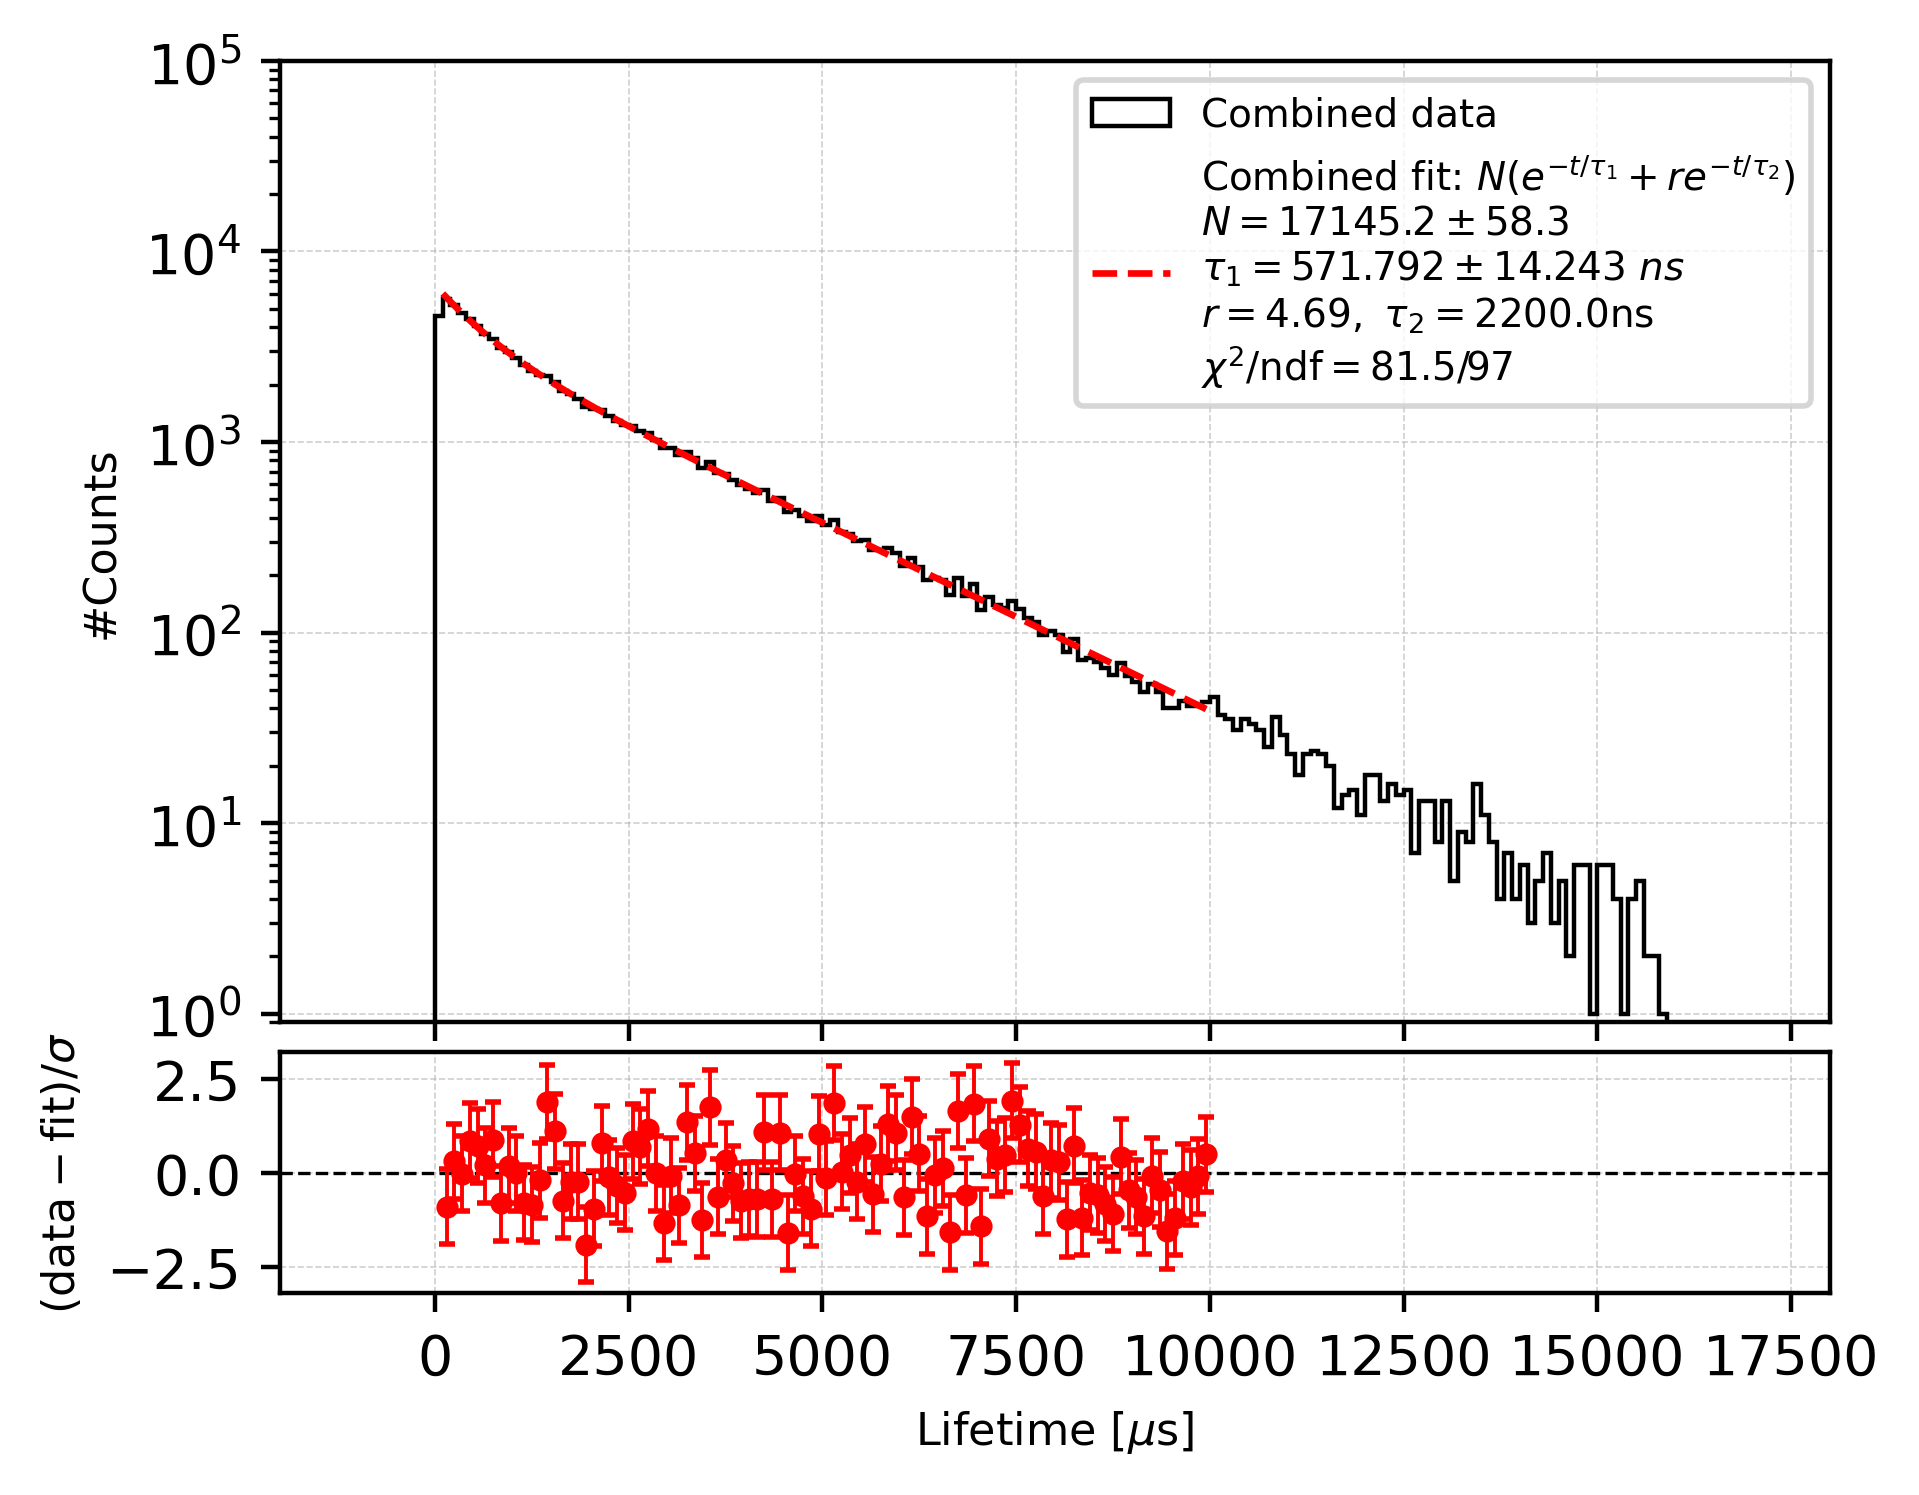

In [12]:
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt


lifetime_trueMichel_initial = [ev.lifetime_initial*1000 for ev in events_true]


# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = 0
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_trueMichel_initial, bins=bins, range=(range_min, range_max),
         edgecolor='black', histtype='step', linewidth=1.0,
         label='Initial True Michel')


plt.xlim(-4000, 16000)
#plt.ylim(0, 500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()




# Bin content printing-----------------------
counts, bin_edges = np.histogram(
    lifetime_trueMichel_initial,
    bins=bins,
    range=(range_min, range_max)
)

# Compute bin centers
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Print line by line
for i in range(len(counts)):
    print(f"Center = {bin_centers[i]:8.0f} ns,  Count = {counts[i]:6d}")
# -------------------------------------------

# -------------------------------------------
# Save the list---
np.save("trueMichel_initial.npy", lifetime_trueMichel_initial)
print("\n\nLength of trueMichel_initial: ", len(lifetime_trueMichel_initial))
# -------------------------------------------





# --- double exponential model: bin-integrated ----------------------------------
# The fitting function can be updated further! Previous argument wrt Jeugen's ---
def exp2_integrated(bin_edges, N, tau1, ratio=1.2, tau2=2200.0):
    """
    Expected counts per bin = integral over each bin for 
    N * exp(-t/tau1) + N * ratio * exp(-t/tau2)
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)

# --- fitting helper (χ² least squares with integrated model) ---
def fit_and_draw(ax, ax_resid, sample, label_prefix, fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red",
                 ratio=1.2, tau2=2200.0):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # fit window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m]
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, label=f"{label_prefix} data", color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0]: m.nonzero()[0][-1] + 2]
    sigma = np.sqrt(np.maximum(y, 1.0))

    # initial guesses
    N0 = np.sum(y)
    tau1_0 = 1000.0

    # fit using double exponential integrated model
    popt, pcov = curve_fit(
        lambda edges, N, tau1: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y,
        p0=[N0, tau1_0],
        sigma=sigma, absolute_sigma=True,
        bounds=([0, 1e-6], [np.inf, np.inf])
    )
    N_fit, tau1_fit = popt
    N_err, tau1_err = np.sqrt(np.diag(pcov))

    # chi²/ndf
    y_model = exp2_integrated(edges_fit, *popt, ratio=ratio, tau2=tau2)
    pulls = (y - y_model) / sigma
    chi2 = np.sum(pulls**2)
    ndf = len(y) - len(popt)

    # smooth curve for visualization
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_fit / tau1_fit) * np.exp(-x_smooth / tau1_fit) * bin_width \
               + (N_fit * ratio / tau2) * np.exp(-x_smooth / tau2) * bin_width

    # draw histogram
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, label=f"{label_prefix} data", color=hist_color)

    # draw fit
    ax.plot(x_smooth, y_smooth,
            label=(fr"{label_prefix} fit: $N(e^{{-t/\tau_1}} + r e^{{-t/\tau_2}})$" + "\n"
                   + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.3f}\pm{tau1_err:.3f}\ ns$" + "\n"
                   + rf"$r={ratio},\ \tau_2={tau2}$" + "ns" + "\n"
                   + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"),
            color=fit_color, linestyle="--", linewidth=1.2)

    # residuals (pulls)
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    return tau1_fit, tau1_err, chi2, ndf


#----------------------------------------
bin_width = 100
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit example-------------------------------------------
fit_and_draw(ax, ax_resid, np.asarray(lifetime_trueMichel_initial), "Combined",
             fit_range=(100, 10000),
             hist_color="black", fit_color="red",
             ratio=4.69, tau2=2200.0)
# ------------------------------------------------------

# Style top plot
ax.set_ylim(0.9, 100000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
#ax.set_title("Lifetime distributions: Michel $e^+$ (Double Exp Fit)", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# Style residuals
ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [$\mu$s]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()




<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [65]:
initial_MS_reco = []#To be consistent with data---
Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---

initial_MS_true = []
Space_events_true = []
MS_events_true = []
MH_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

    if 0.1 < MS:
        initial_MS_reco.append(ev)
        if E > 0:
            initial_MS_true.append(ev)

        #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
        if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
            Space_events_reco.append(ev)
            if E > 0:
                Space_events_true.append(ev)

            if 0.2 < MS: #(Michel score cut)---
                MS_events_reco.append(ev)
                if E > 0:
                    MS_events_true.append(ev)
            
                if 2 <MH: #Michel hits cut---                
                    MH_events_reco.append(ev)
                    if E > 0:
                        MH_events_true.append(ev) 
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))
print("True events (initial): ", len(events_true), "({:.2f}%)".format(len(events_true)/len(events_reco)*100))

print("\nReco events (MS>0.1): ", len(initial_MS_reco))
print("True events (MS>0.1): ", len(initial_MS_true), "({:.2f}%)".format(len(initial_MS_true)/len(initial_MS_reco)*100))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))
print("True events (Space cut): ", len(Space_events_true), "({:.2f}%)".format(len(Space_events_true)/len(Space_events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))
print("True events (Space & MS cuts): ", len(MS_events_true), "({:.2f}%)".format(len(MS_events_true)/len(MS_events_reco)*100))


print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(MH_events_true), "({:.2f}%)".format(len(MH_events_true)/len(MH_events_reco)*100))








Reco events (initial):  141884
True events (initial):  30246 (21.32%)

Reco events (MS>0.1):  68676
True events (MS>0.1):  27387 (39.88%)

Reco events (Space cut):  38224 (26.94%)
True events (Space cut):  23714 (62.04%)

Reco events (Space & MS cuts):  31617 (22.28%)
True events (Space & MS cuts):  22429 (70.94%)

Reco events (Space & MS & MH cuts):  29629 (20.88%)
True events (Space & MS & MH cuts):  21855 (73.76%)



### Apply all cuts:

In [43]:

TPC_events_reco = [] # After Space & MS & MH cuts---

TPC_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if 0.4 < MS: #(Michel score cut)---
            
            if 5 <MH: #Michel hits cut---                
                TPC_events_reco.append(ev)
                if E > 0:
                    TPC_events_true.append(ev) 



print("\nReco events (Space & MS & MH cuts): ", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(TPC_events_true), 
      "({:.2f}%)".format(len(TPC_events_true)/len(TPC_events_reco)*100))





Reco events (Space & MS & MH cuts):  19673 (13.87%)
True events (Space & MS & MH cuts):  17286 (87.87%)


Decay points distribution (After TPC cut): 
# of X < 0 :  7330 (37.259%)
# of X >= 0:  12343 (62.741%)

#decayX_TPC (total):  19673
#decayX_apa1:  267 (1.36%)
#decayX_apa2:  7063 (35.90%)
#decayX_apa3:  5780 (29.38%)
#decayX_apa4:  6563 (33.36%)


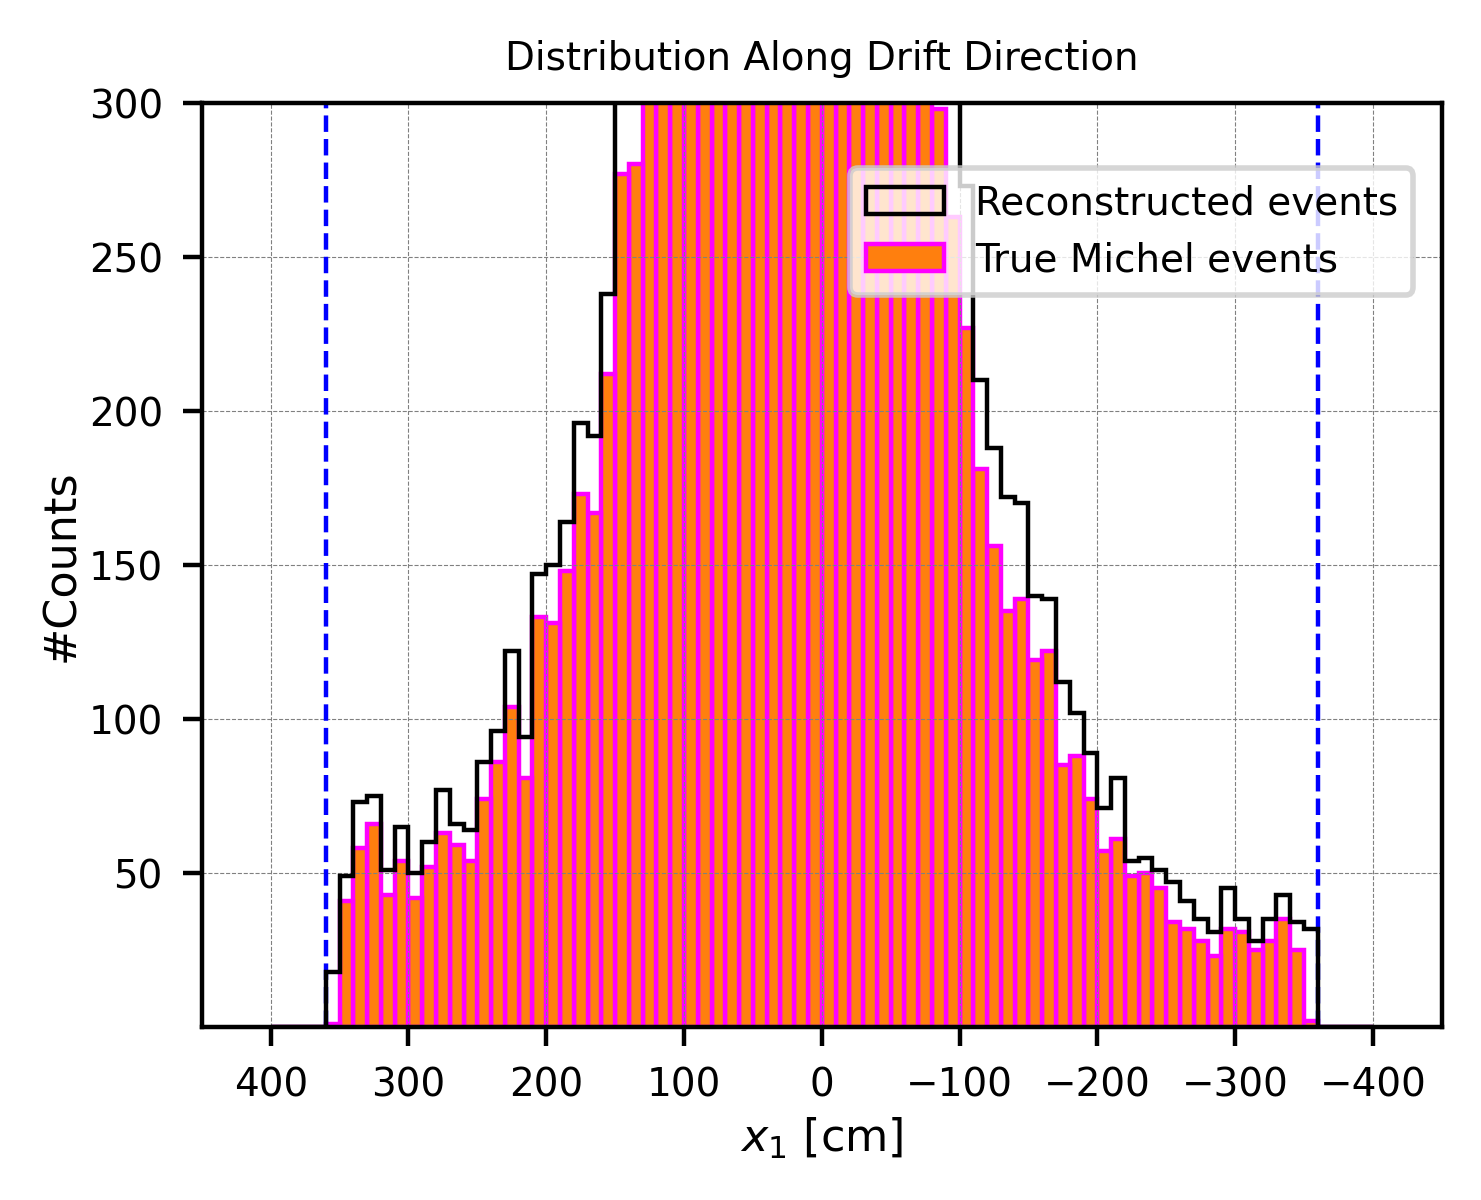

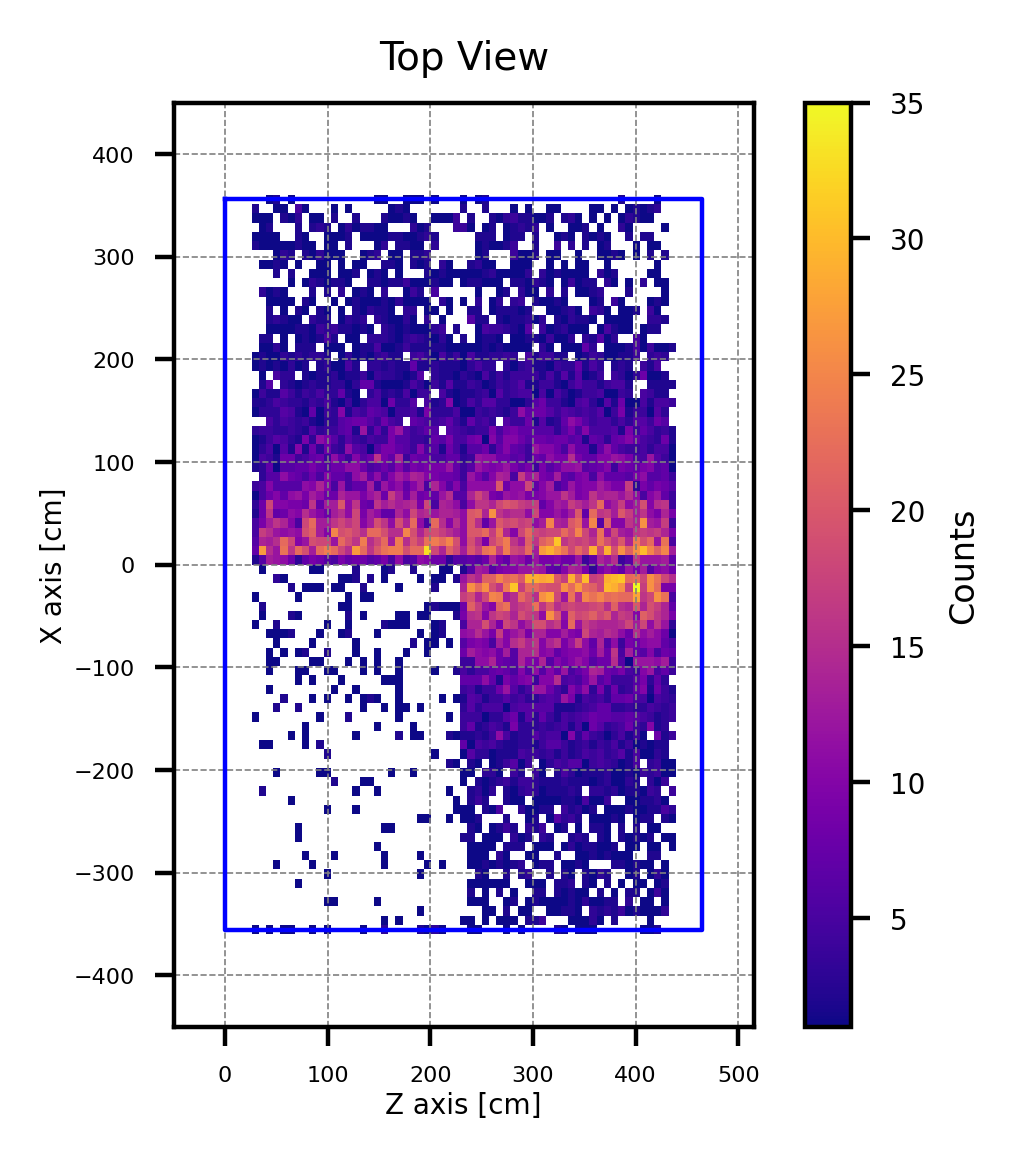

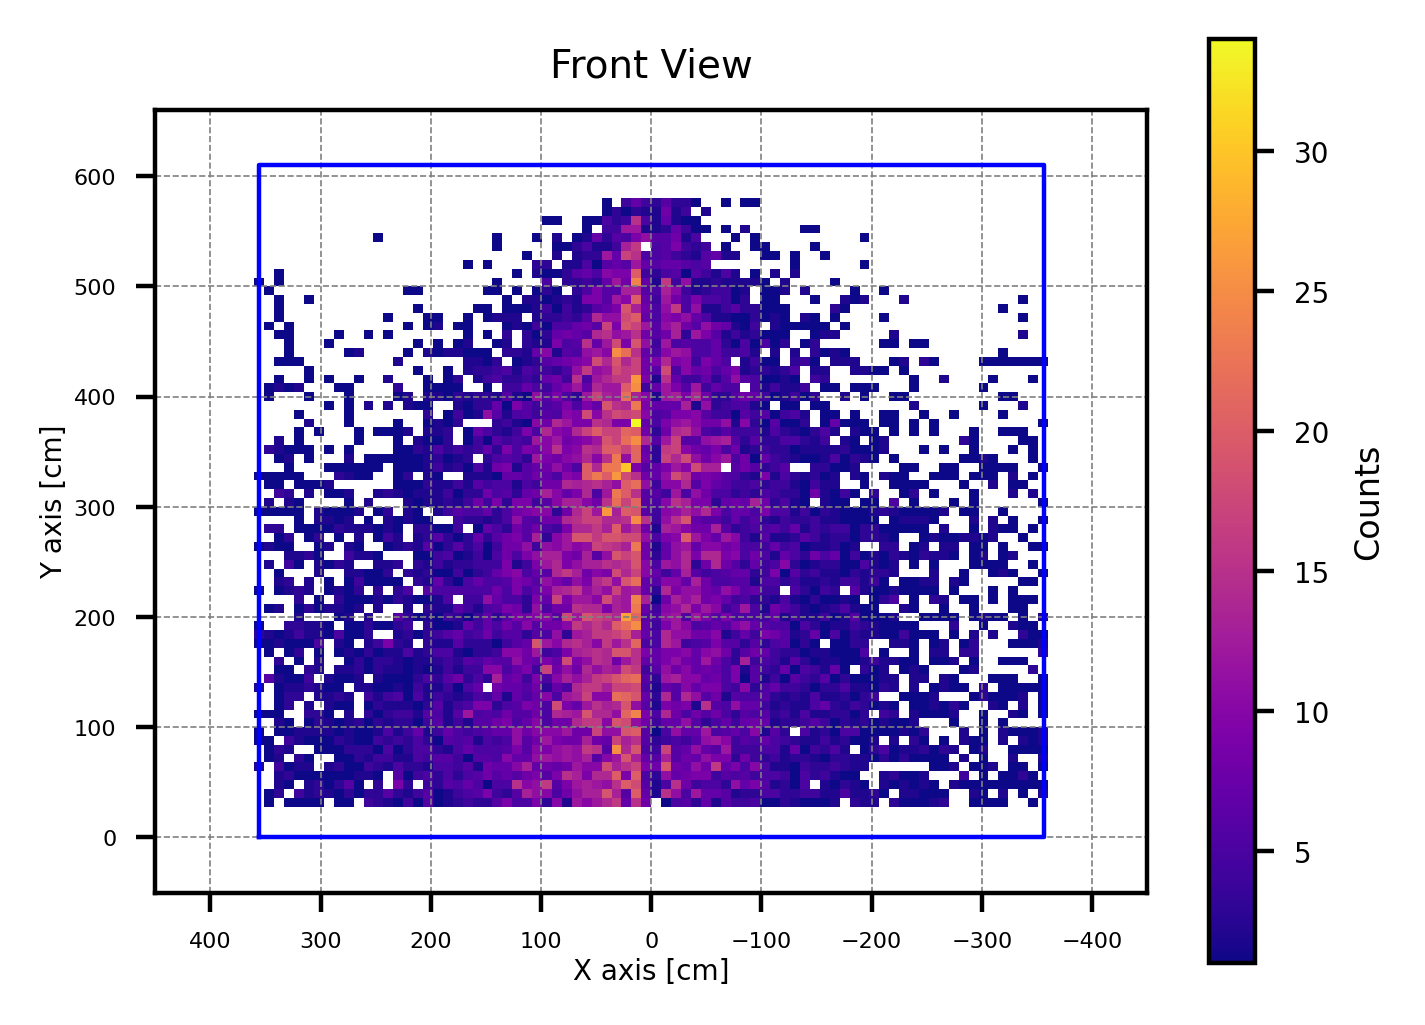

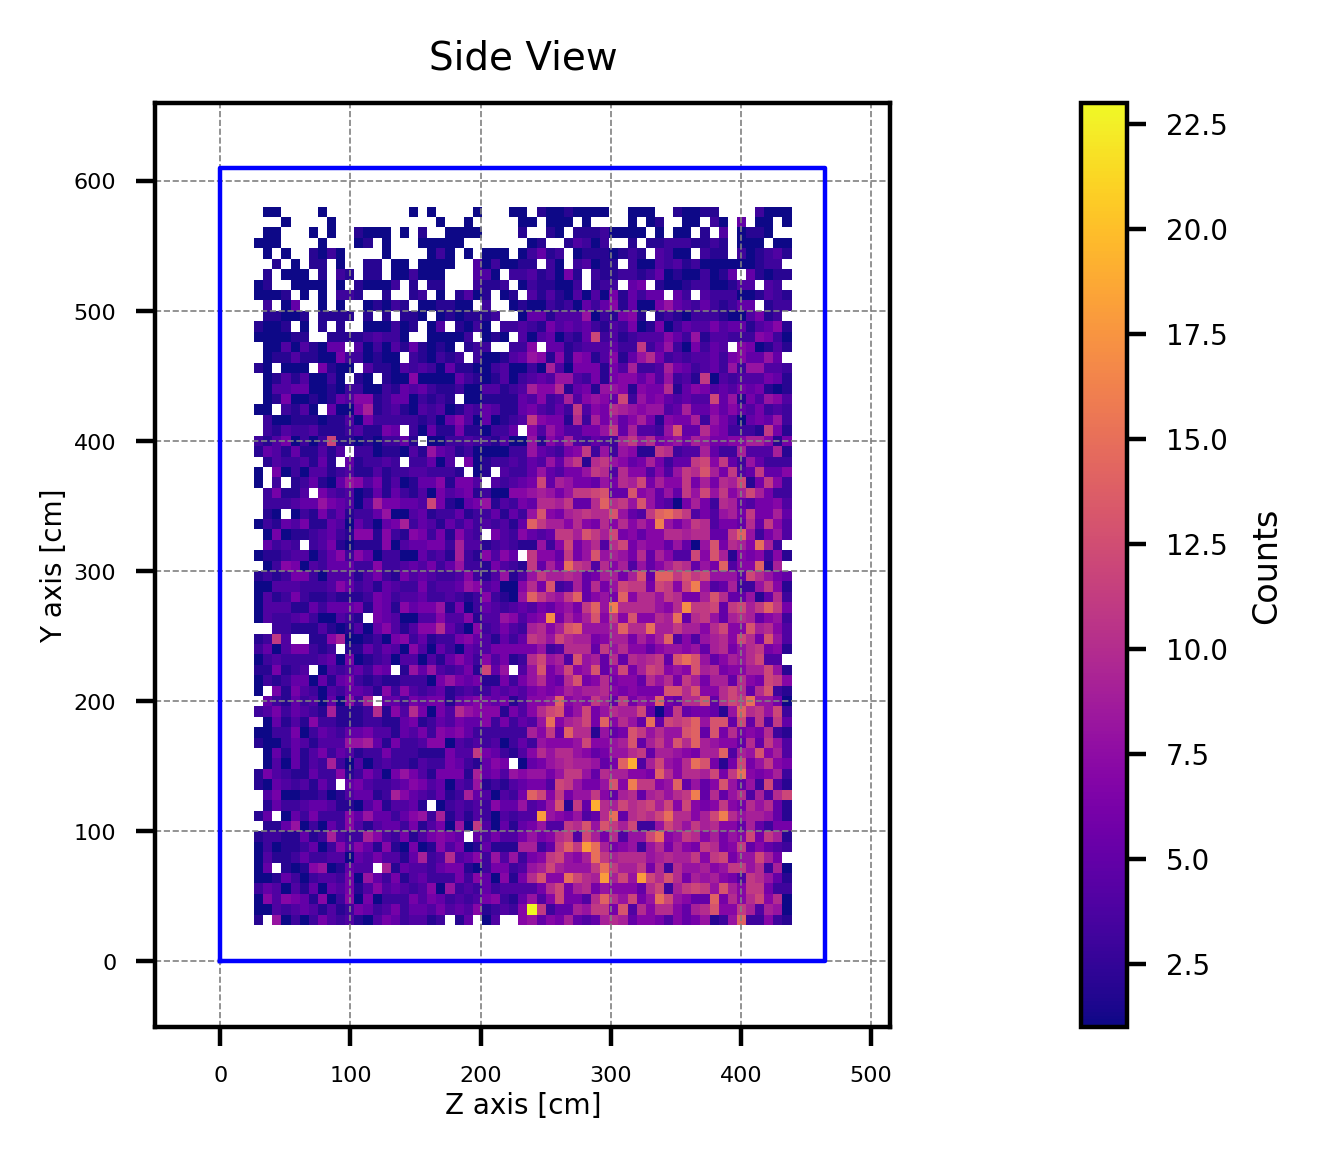

<Figure size 1600x1200 with 0 Axes>

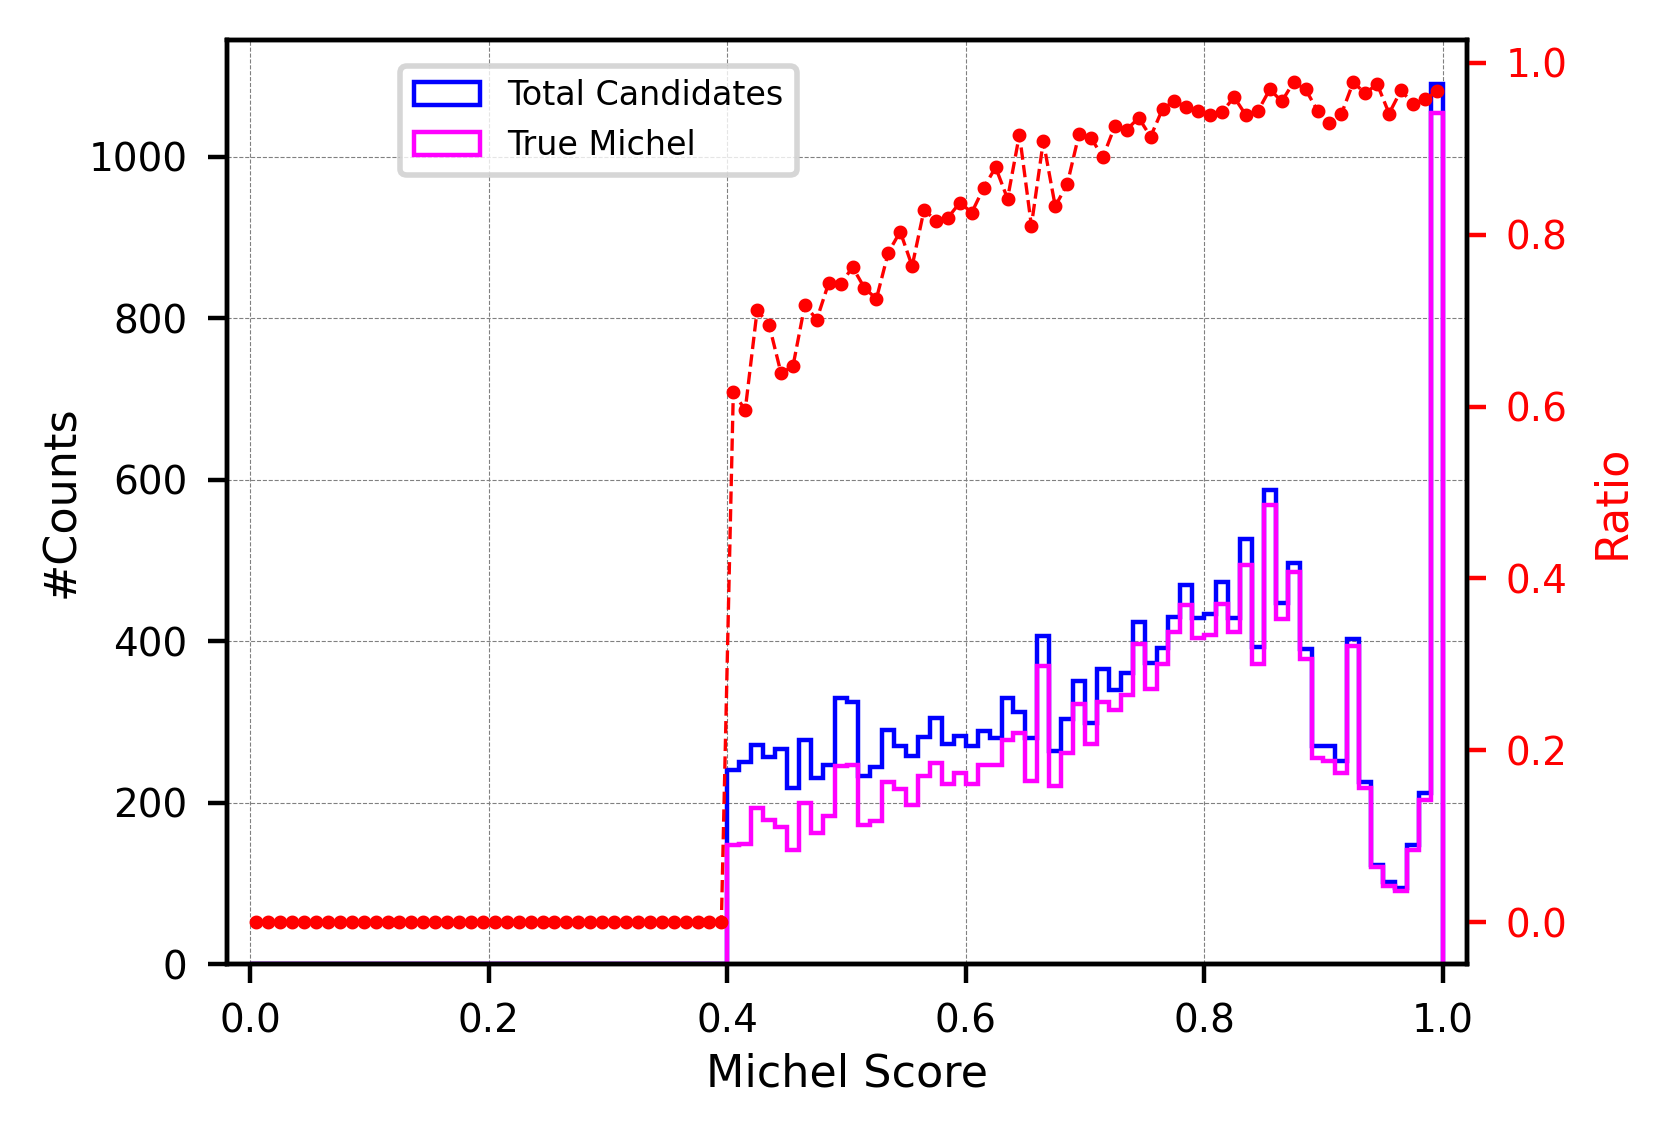

<Figure size 1600x1200 with 0 Axes>

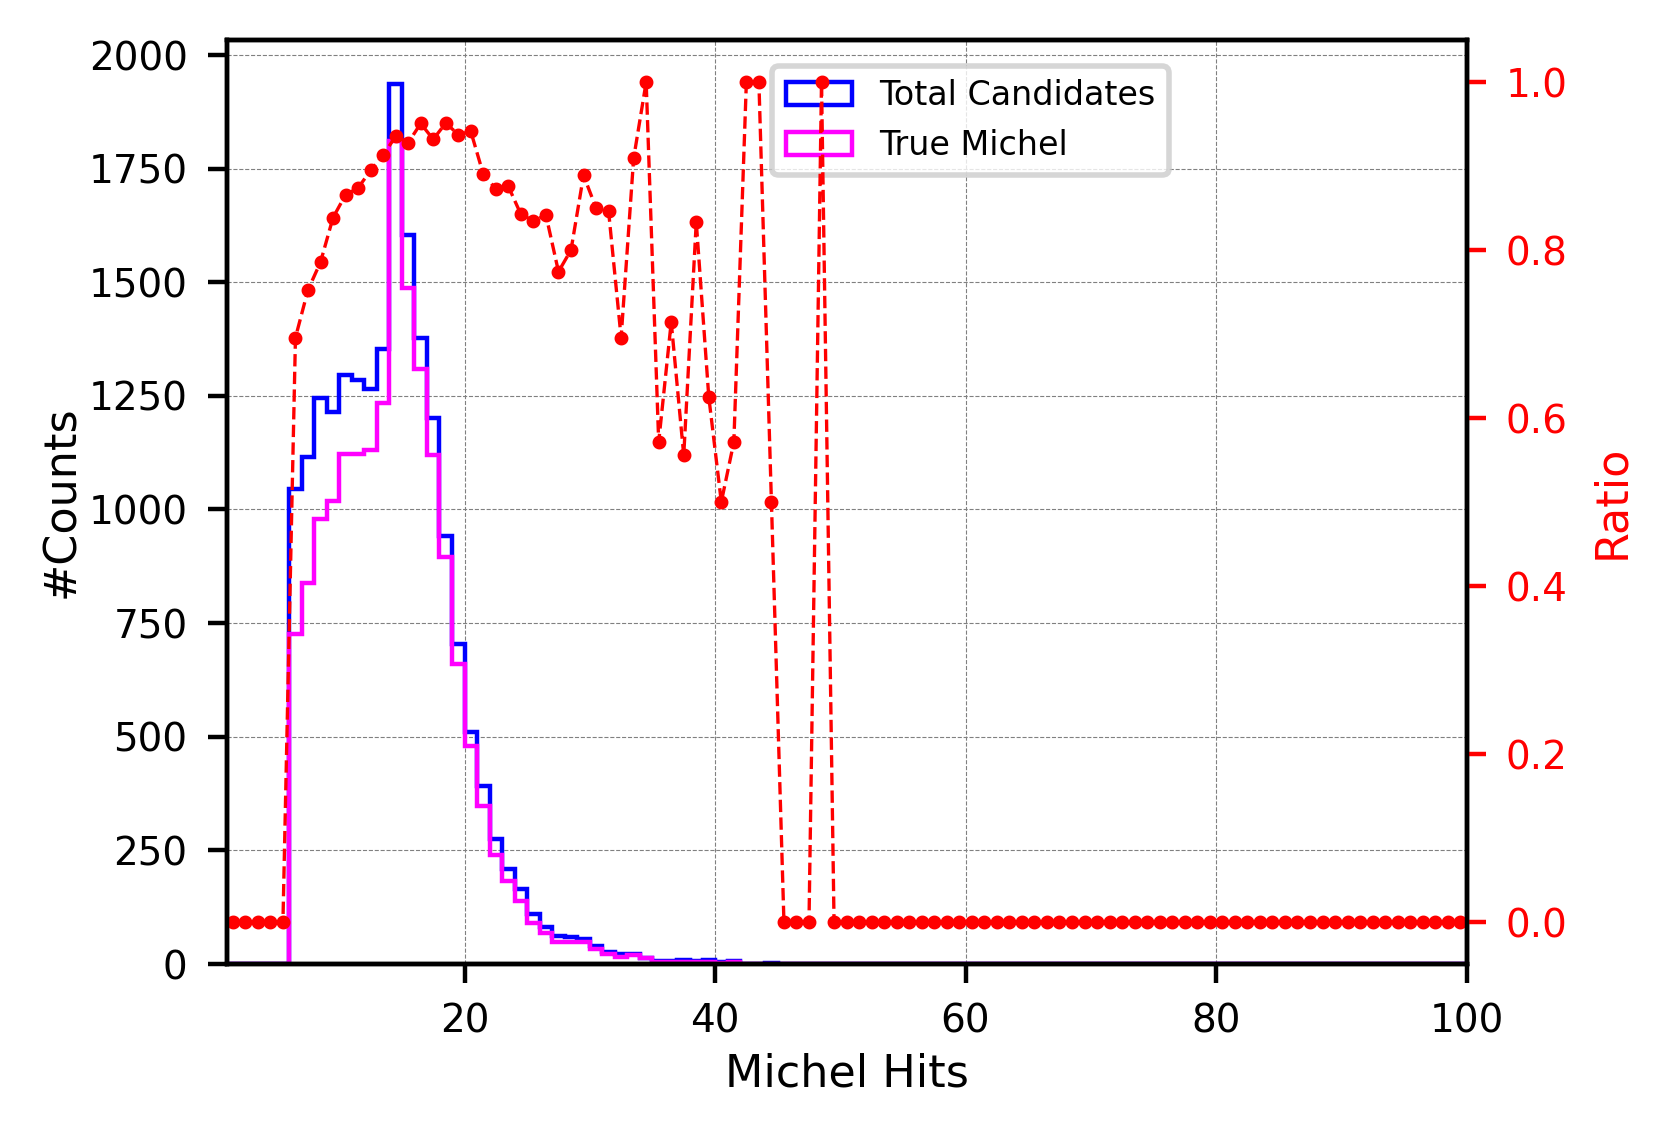




Starting points distribution: 


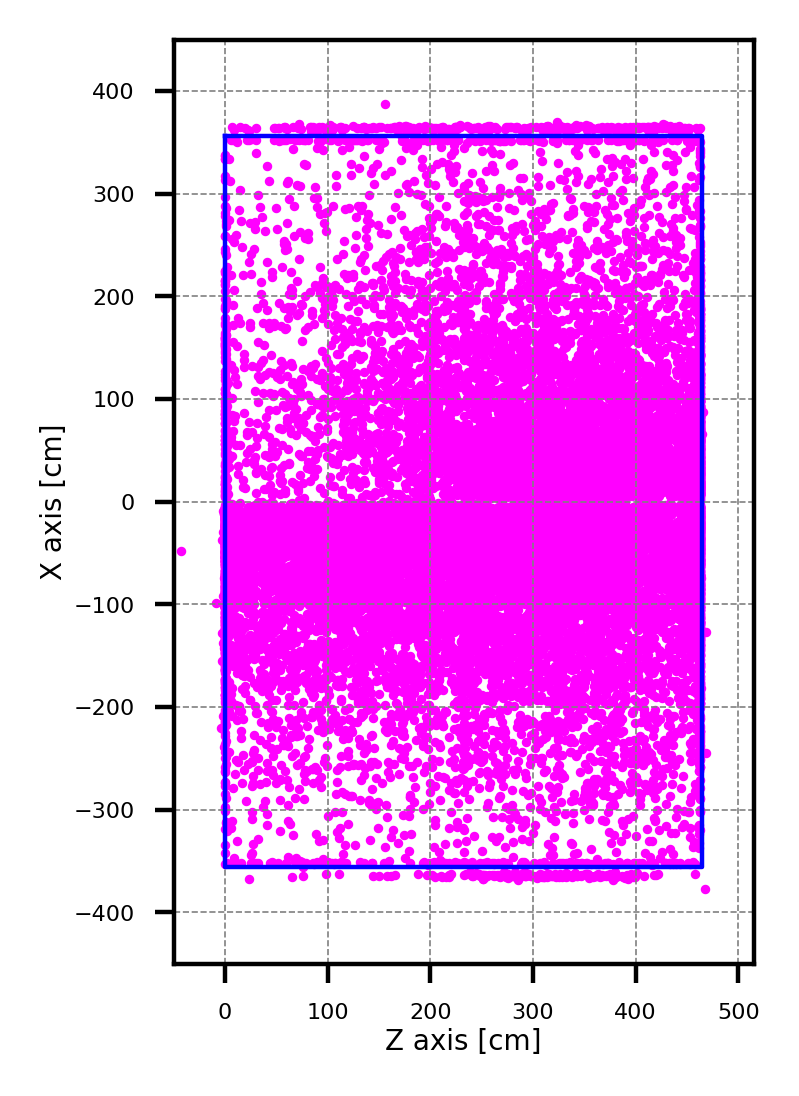

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]


TPC_X_true = [ev.decayX_initial for ev in TPC_events_true]
TPC_Y_true = [ev.decayY_initial for ev in TPC_events_true]
TPC_Z_true = [ev.decayZ_initial for ev in TPC_events_true]
TPC_MS_true = [ev.MS_initial for ev in TPC_events_true]
TPC_MH_true = [ev.MH_initial for ev in TPC_events_true]




#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(TPC_X_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(100, 100), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 









#Michel score distribution ----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MS, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02)
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show()









 

#Michel hits distribution -----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MH, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.6, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show() 








#Starting points distribution:==========================================
print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(TPC_startZ, TPC_startX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()



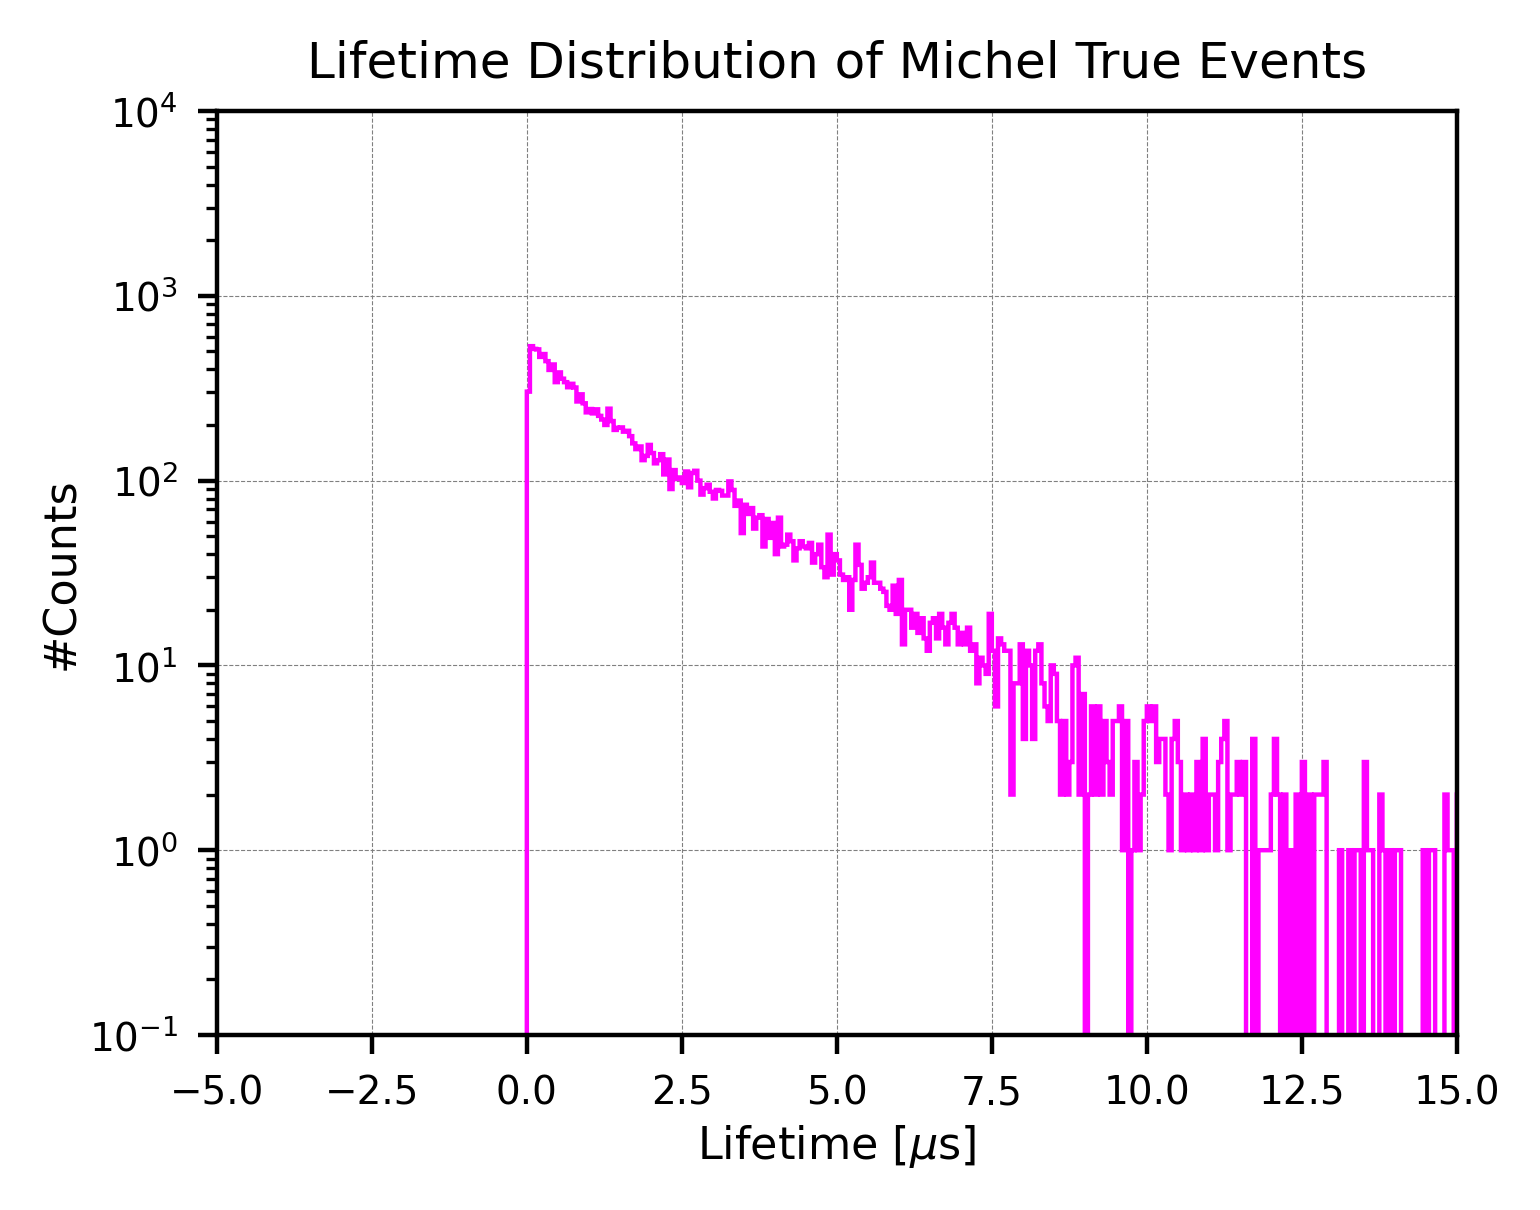

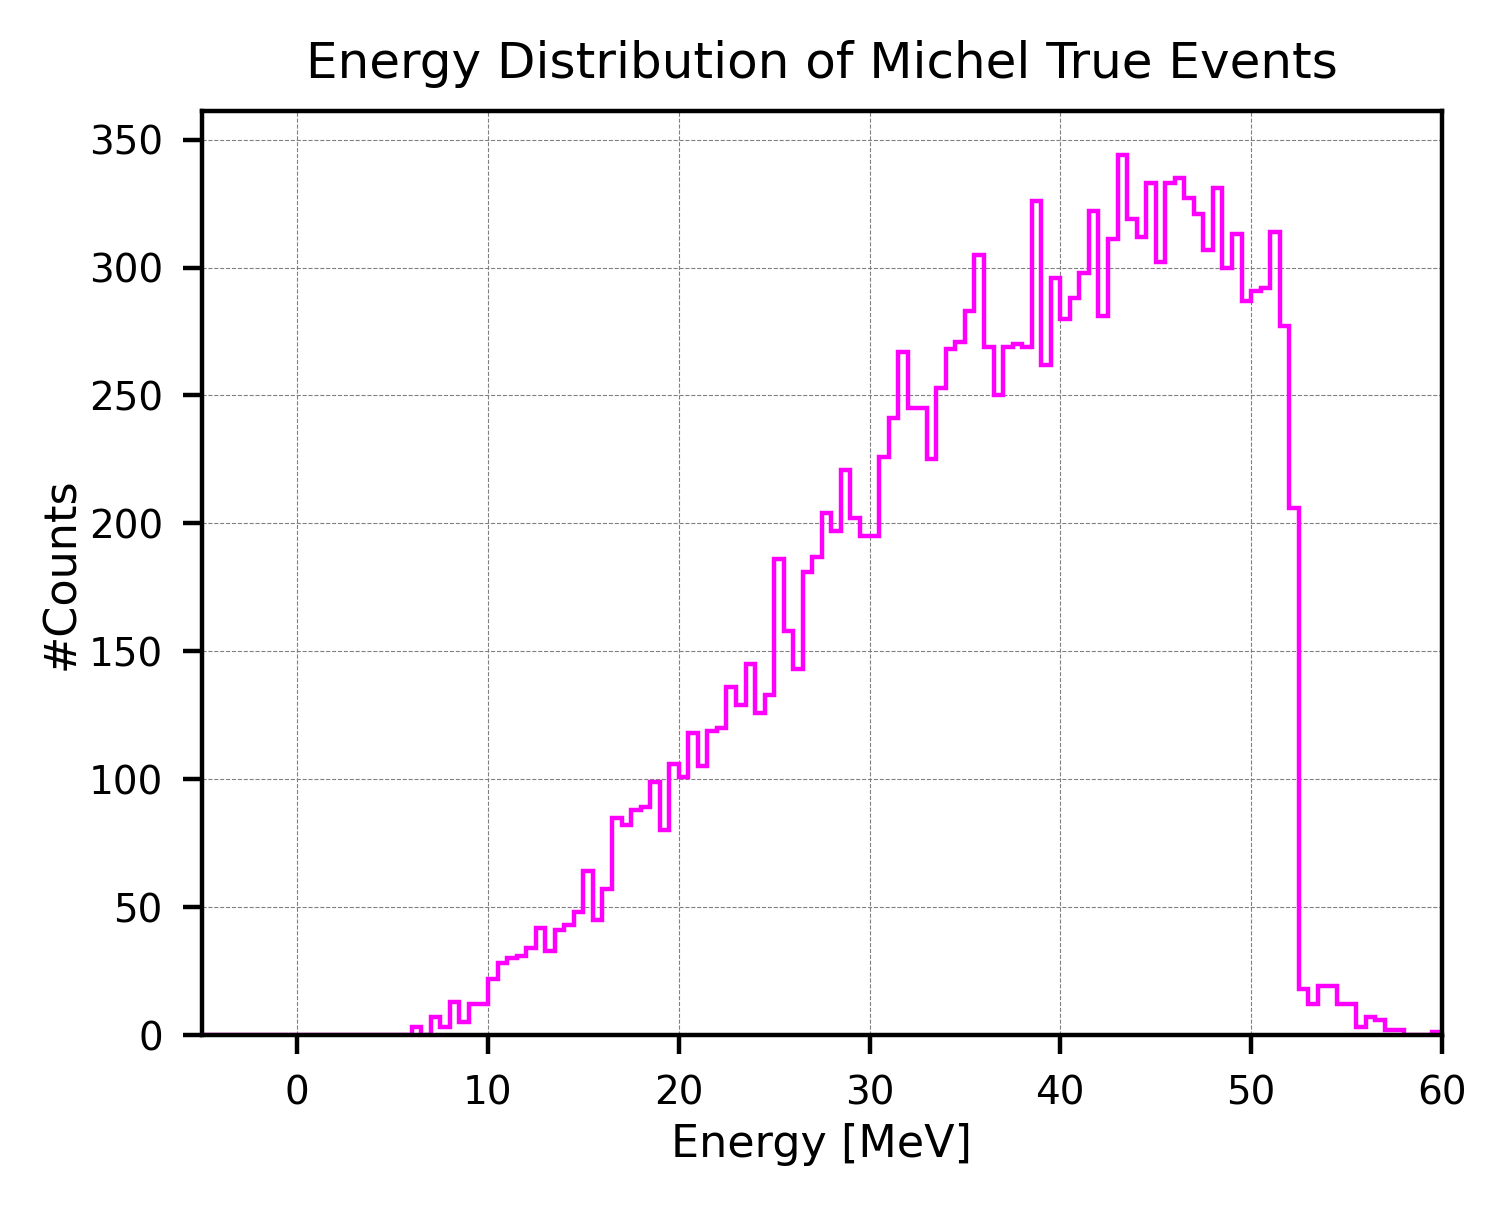

In [45]:

TPC_lifetime_true = [ev.lifetime_initial for ev in TPC_events_true]
TPC_energy_true = [ev.energy_initial for ev in TPC_events_true]


#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_lifetime_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 15)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 10000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  










#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  


### New fittings:

(TPC cut) Michel e^+  :  14320 / 19673 (72.79%)
(TPC cut) Michel e^-  :  2966 / 19673 (15.08%)
(TPC cut) False Michel:  2966 / 19673 (15.08%)


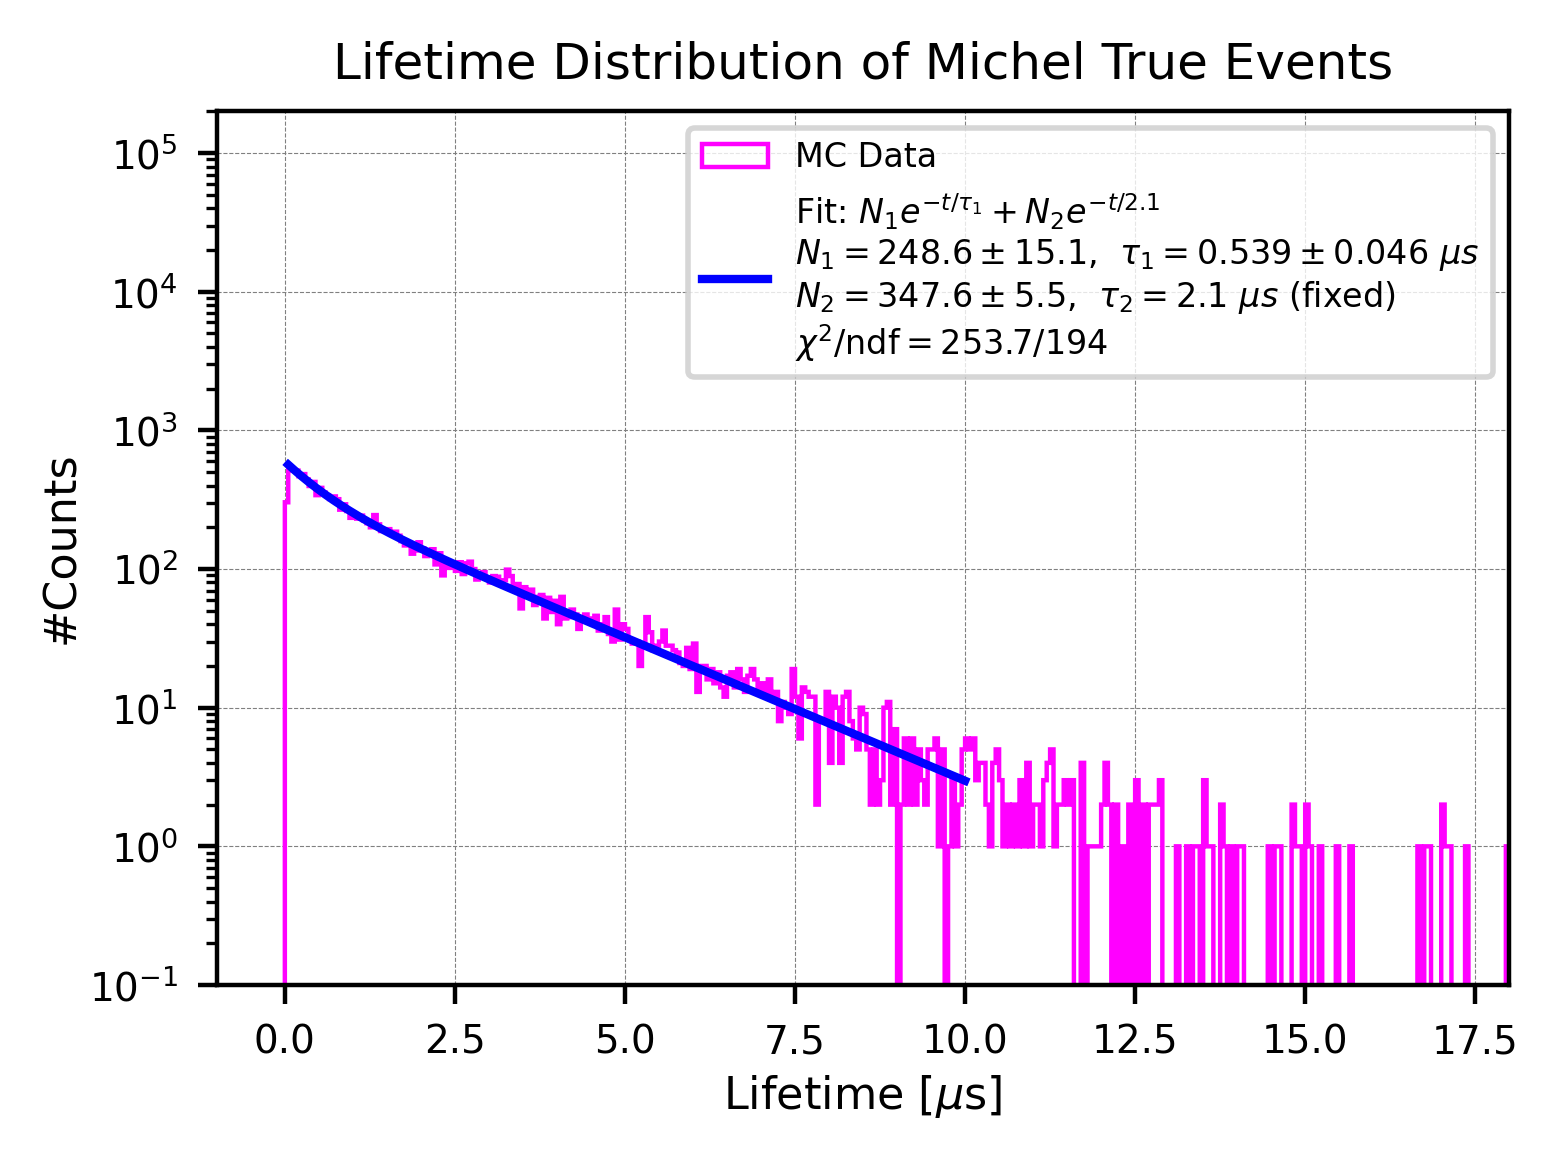

N1 = 248.647 ± 15.123
tau1 = 0.53912 ± 0.04600 us
N2 = 347.629 ± 5.454
chi2/ndf = 253.73/194 = 1.308


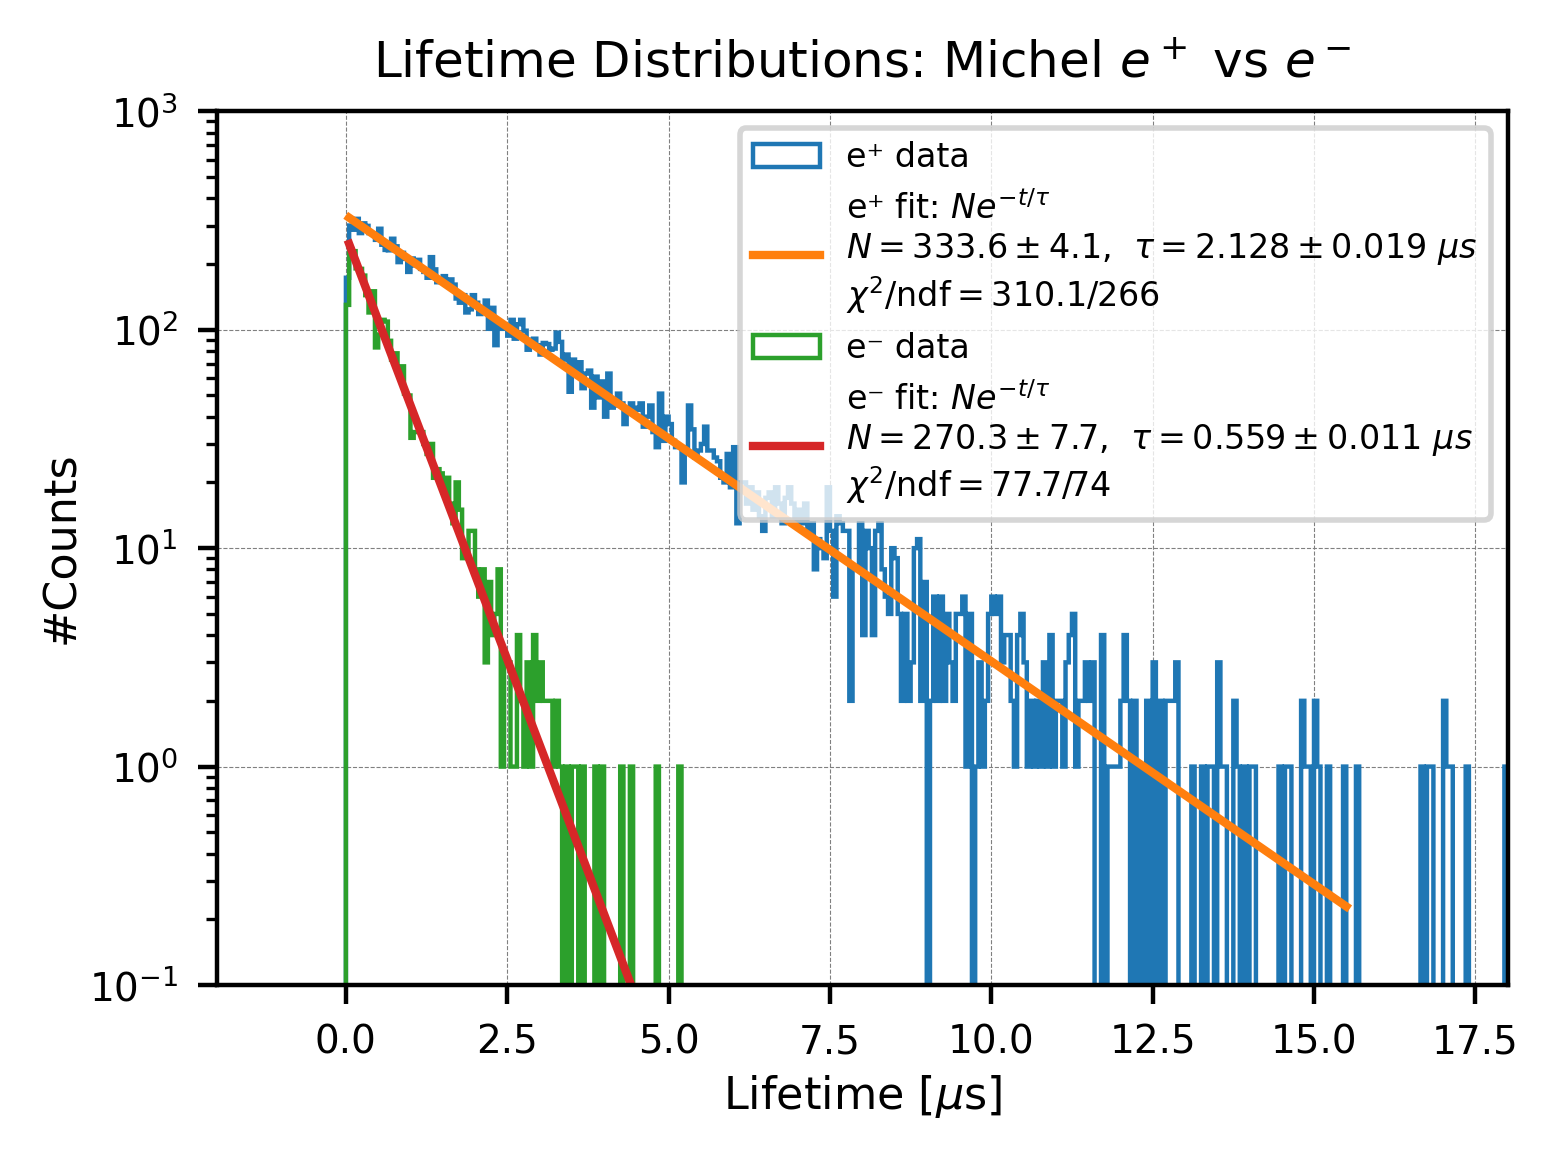

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# Seperate Michel e^- and e^+ (true events)------------------------------
TPC_life_pM = []
TPC_life_nM = []
count = 0
for ev in TPC_events_reco:
    pdg = ev.pdg_initial
    life = ev.lifetime_initial

    if pdg < 0:
        TPC_life_pM.append(life)
    elif pdg > 0:
        TPC_life_nM.append(life)
    elif pdg == 0:
        count += 1

print("(TPC cut) Michel e^+  : ", len(TPC_life_pM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_pM)/len(TPC_events_reco)*100))
print("(TPC cut) Michel e^-  : ", len(TPC_life_nM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_nM)/len(TPC_events_reco)*100))
print("(TPC cut) False Michel: ", len(TPC_life_nM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_nM)/len(TPC_events_reco)*100))








# Define the new exponential decay function===========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Exponential decay model (bin-by-bin, tau2 fixed)
# ============================================================
def exp_decay(t, N1, tau1, N2):
    return N1 * np.exp(-t / tau1) + N2 * np.exp(-t / 2.1)

# ============================================================
# Histogram setup
# ============================================================
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Histogram the data
counts, bin_edges = np.histogram(TPC_lifetime_true, bins=bins, range=(range_min, range_max))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# ============================================================
# Select fitting region
# ============================================================
fit_mask = (bin_centers >= 0.05) & (bin_centers <= 10)
x_fit_all = bin_centers[fit_mask]
y_fit_all = counts[fit_mask]

# Skip zero bins (avoid div by 0 in weights)
nz = y_fit_all > 0
x_fit = x_fit_all[nz]
y_fit = y_fit_all[nz]
sigma = np.sqrt(y_fit)  # Poisson errors

# ============================================================
# Initial guesses
# ============================================================
N1_0 = float(np.max(y_fit)) if y_fit.size else 1.0
tau1_0 = 2.0
N2_0 = max(N1_0 / 10.0, 1.0)

# ============================================================
# Weighted least squares fit
# ============================================================
popt, pcov = curve_fit(
    exp_decay, x_fit, y_fit,
    p0=[N1_0, tau1_0, N2_0],
    sigma=sigma,
    absolute_sigma=True,
    bounds=([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf]),
    maxfev=20000,
)
N1_fit, tau1_fit, N2_fit = popt
perr = np.sqrt(np.diag(pcov))
N1_err, tau1_err, N2_err = perr

# ============================================================
# Chi² / ndf
# ============================================================
y_exp = exp_decay(x_fit, *popt)
residual = (y_fit - y_exp) / sigma
chi2 = np.sum(residual**2)
ndf = max(len(x_fit) - len(popt), 1)
chi2_ndf = chi2 / ndf

# ============================================================
# Smooth curve for plotting
# ============================================================
x_smooth = np.linspace(0.05, 10, 500)
y_smooth = exp_decay(x_smooth, *popt)

# ============================================================
# Plot histogram
# ============================================================
plt.hist(TPC_lifetime_true, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8, label="MC Data")

# Plot fitted curve
plt.plot(
    x_smooth, y_smooth, 'b-',
    label=(
        r'Fit: $N_1 e^{-t/\tau_1} + N_2 e^{-t/2.1}$' + '\n'
        + rf'$N_1={N1_fit:.1f}\pm{N1_err:.1f}$,  $\tau_1={tau1_fit:.3f}\pm{tau1_err:.3f}\ \mu s$' + '\n'
        + rf'$N_2={N2_fit:.1f}\pm{N2_err:.1f}$,  $\tau_2=2.1\ \mu s$ (fixed)' + '\n'
        + rf'$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$'
    )
)

# ============================================================
# Style
# ============================================================
plt.xlim(-1, 18)
plt.ylim(0.1, 200000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()

# ============================================================
# Print results
# ============================================================
print(
    f"N1 = {N1_fit:.3f} ± {N1_err:.3f}\n"
    f"tau1 = {tau1_fit:.5f} ± {tau1_err:.5f} us\n"
    f"N2 = {N2_fit:.3f} ± {N2_err:.3f}\n"
    f"chi2/ndf = {chi2:.2f}/{ndf} = {chi2_ndf:.3f}"
)













#Fitting seperating for Michel e^+ and e^-===============================================

# --- single exponential ---
def exp1(t, N, tau):
    return N * np.exp(-t / tau)

# --- plotting / binning setup ---
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.05
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- helper: weighted fit (σ = sqrt(y)), skip zeros, draw ---
def fit_and_draw(sample, label_prefix, fit_range=(0.05, 15.5)):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # choose fit window & drop zero bins
    m = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    x_all = bin_centers[m]
    y_all = counts[m]
    nz = y_all > 0
    x_fit = x_all[nz]
    y_fit = y_all[nz]

    # abort gracefully if too few points
    if len(y_fit) < 3:
        plt.hist(sample, bins=bins, range=(range_min, range_max),
                 histtype='step', linewidth=0.8, label=f"{label_prefix} MC data")
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    sigma = np.sqrt(y_fit)

    # safe initial guesses & bounds
    N0, tau0 = float(np.max(y_fit)), 2.0
    bounds = ([0.0, 1e-6], [np.inf, np.inf])

    # weighted least squares
    popt, pcov = curve_fit(
        exp1, x_fit, y_fit, p0=[N0, tau0],
        sigma=sigma, absolute_sigma=True,
        bounds=bounds, maxfev=20000
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi2/ndf
    y_mod = exp1(x_fit, *popt)
    r = (y_fit - y_mod) / sigma
    chi2 = float(np.sum(r**2))
    ndf = max(len(x_fit) - len(popt), 1)
    chi2_ndf = chi2 / ndf

    # smooth curve
    x_smooth = np.linspace(fit_range[0], fit_range[1], 500)
    y_smooth = exp1(x_smooth, *popt)

    # draw histogram (step)
    plt.hist(sample, bins=bins, range=(range_min, range_max),
             histtype='step', linewidth=0.8, label=f"{label_prefix} data")

    # draw fit
    plt.plot(
        x_smooth, y_smooth,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$,  $\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    return (N_fit, tau_fit, N_err, tau_err, chi2_ndf)

# ---- run for both lists ----
N_p, tau_p, dN_p, dtau_p, chi2ndf_p = fit_and_draw(np.asarray(TPC_life_pM), "e⁺")
N_n, tau_n, dN_n, dtau_n, chi2ndf_n = fit_and_draw(np.asarray(TPC_life_nM), "e⁻")

# --- final plot cosmetics (kept similar to your style) ---
plt.xlim(-2, 18)
plt.ylim(0.1, 1000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distributions: Michel $e^+$ vs $e^-$', fontsize=9)
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()



